In [2]:
from ultralytics import YOLO
import cv2
import glob
import numpy as np
from scipy.spatial import ConvexHull
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import networkx as nx
from sklearn.cluster import MeanShift, estimate_bandwidth
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns

### Test model

In [51]:
# Load a model
model = YOLO("./models/detect-shape_v4.pt")

In [52]:
images = glob.glob("images/shape/gray_image_*.jpg")
images = sorted(images, reverse=True)
# images = images[1:14]

In [53]:
imgs = []

for i in images:
    img = cv2.imread(i, cv2.IMREAD_COLOR)

    img_res = cv2.erode(img, cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3)), iterations=15)
    imgs.append(cv2.bitwise_not(img_res))

In [58]:
# images

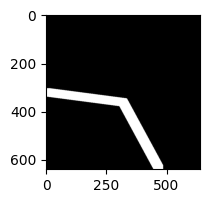


0: 256x256 l 0.98, i 0.02, c 0.00, 3.1ms
Speed: 4.8ms preprocess, 3.1ms inference, 0.0ms postprocess per image at shape (1, 3, 256, 256)


'Letra detectada: l confianza: 98.06692004203796'

In [85]:
img_selected = 20 # len(images) - 1

plt.imshow(imgs[img_selected])
# plt.axis('off')
# Modificar el tamaño de la imagen
plt.gcf().set_size_inches(2, 2)
plt.show()

res = model(imgs[img_selected])
"Letra detectada: " +  res[0].names[res[0].probs.top1] + " confianza: " + str(res[0].probs.top1conf.item() * 100)

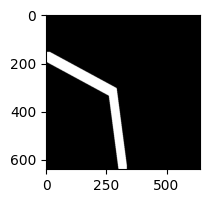


0: 256x256 l 0.99, i 0.01, c 0.00, 4.6ms
Speed: 8.9ms preprocess, 4.6ms inference, 0.1ms postprocess per image at shape (1, 3, 256, 256)
Letra detectada: l confianza: 99.04668927192688


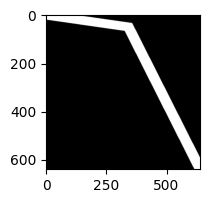


0: 256x256 l 0.41, i 0.41, c 0.18, 3.1ms
Speed: 4.4ms preprocess, 3.1ms inference, 0.0ms postprocess per image at shape (1, 3, 256, 256)
Letra detectada: l confianza: 41.452571749687195


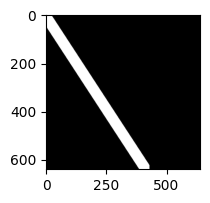


0: 256x256 i 1.00, l 0.00, c 0.00, 2.9ms
Speed: 4.7ms preprocess, 2.9ms inference, 0.0ms postprocess per image at shape (1, 3, 256, 256)
Letra detectada: i confianza: 99.99998807907104


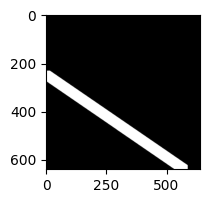


0: 256x256 i 1.00, l 0.00, c 0.00, 3.0ms
Speed: 4.2ms preprocess, 3.0ms inference, 0.0ms postprocess per image at shape (1, 3, 256, 256)
Letra detectada: i confianza: 99.9998927116394


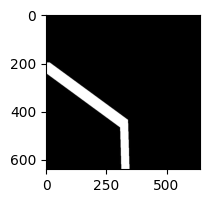


0: 256x256 l 0.99, i 0.01, c 0.00, 2.9ms
Speed: 4.7ms preprocess, 2.9ms inference, 0.0ms postprocess per image at shape (1, 3, 256, 256)
Letra detectada: l confianza: 98.96601438522339


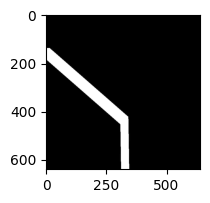


0: 256x256 l 0.96, i 0.04, c 0.00, 3.2ms
Speed: 5.0ms preprocess, 3.2ms inference, 0.0ms postprocess per image at shape (1, 3, 256, 256)
Letra detectada: l confianza: 96.07598185539246


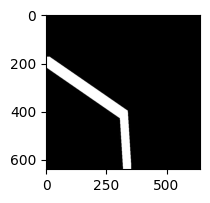


0: 256x256 l 0.99, i 0.01, c 0.00, 3.1ms
Speed: 4.4ms preprocess, 3.1ms inference, 0.0ms postprocess per image at shape (1, 3, 256, 256)
Letra detectada: l confianza: 98.81631731987


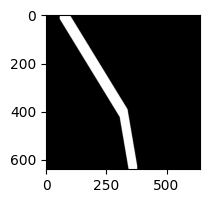


0: 256x256 i 1.00, l 0.00, c 0.00, 3.2ms
Speed: 4.5ms preprocess, 3.2ms inference, 0.0ms postprocess per image at shape (1, 3, 256, 256)
Letra detectada: i confianza: 99.99881982803345


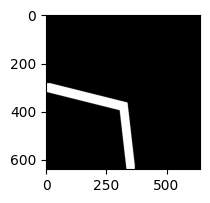


0: 256x256 l 1.00, c 0.00, i 0.00, 4.6ms
Speed: 7.3ms preprocess, 4.6ms inference, 0.0ms postprocess per image at shape (1, 3, 256, 256)
Letra detectada: l confianza: 99.95139837265015


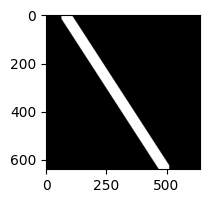


0: 256x256 i 1.00, l 0.00, c 0.00, 3.2ms
Speed: 4.1ms preprocess, 3.2ms inference, 0.0ms postprocess per image at shape (1, 3, 256, 256)
Letra detectada: i confianza: 99.99998807907104


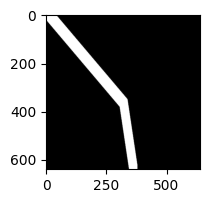


0: 256x256 i 0.99, l 0.01, c 0.00, 9.9ms
Speed: 11.6ms preprocess, 9.9ms inference, 0.1ms postprocess per image at shape (1, 3, 256, 256)
Letra detectada: i confianza: 99.3878960609436


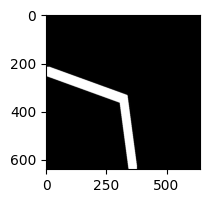


0: 256x256 l 1.00, i 0.00, c 0.00, 2.9ms
Speed: 4.8ms preprocess, 2.9ms inference, 0.0ms postprocess per image at shape (1, 3, 256, 256)
Letra detectada: l confianza: 99.90600943565369


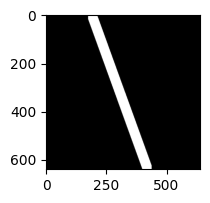


0: 256x256 i 1.00, l 0.00, c 0.00, 2.9ms
Speed: 4.7ms preprocess, 2.9ms inference, 0.0ms postprocess per image at shape (1, 3, 256, 256)
Letra detectada: i confianza: 99.99996423721313


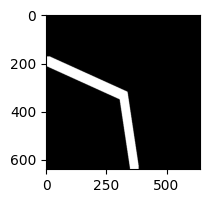


0: 256x256 l 1.00, i 0.00, c 0.00, 4.7ms
Speed: 7.3ms preprocess, 4.7ms inference, 0.1ms postprocess per image at shape (1, 3, 256, 256)
Letra detectada: l confianza: 99.70736503601074


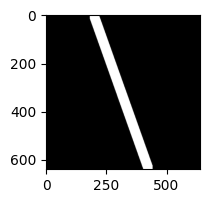


0: 256x256 i 1.00, l 0.00, c 0.00, 3.7ms
Speed: 6.2ms preprocess, 3.7ms inference, 0.0ms postprocess per image at shape (1, 3, 256, 256)
Letra detectada: i confianza: 99.99995231628418


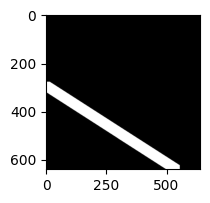


0: 256x256 i 1.00, l 0.00, c 0.00, 3.1ms
Speed: 4.6ms preprocess, 3.1ms inference, 0.0ms postprocess per image at shape (1, 3, 256, 256)
Letra detectada: i confianza: 99.99943971633911


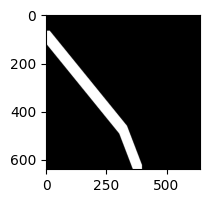


0: 256x256 i 1.00, l 0.00, c 0.00, 7.8ms
Speed: 11.2ms preprocess, 7.8ms inference, 0.1ms postprocess per image at shape (1, 3, 256, 256)
Letra detectada: i confianza: 99.99994039535522


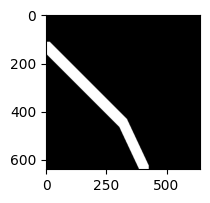


0: 256x256 i 1.00, l 0.00, c 0.00, 2.9ms
Speed: 4.3ms preprocess, 2.9ms inference, 0.0ms postprocess per image at shape (1, 3, 256, 256)
Letra detectada: i confianza: 99.99992847442627


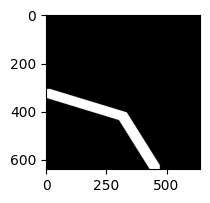


0: 256x256 i 0.92, l 0.08, c 0.00, 3.3ms
Speed: 4.6ms preprocess, 3.3ms inference, 0.0ms postprocess per image at shape (1, 3, 256, 256)
Letra detectada: i confianza: 92.05818772315979


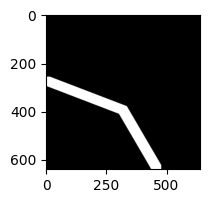


0: 256x256 i 0.99, l 0.01, c 0.00, 3.3ms
Speed: 4.7ms preprocess, 3.3ms inference, 0.0ms postprocess per image at shape (1, 3, 256, 256)
Letra detectada: i confianza: 98.87591600418091


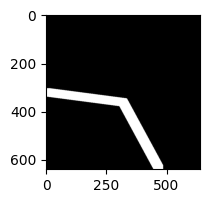


0: 256x256 l 0.98, i 0.02, c 0.00, 8.2ms
Speed: 11.4ms preprocess, 8.2ms inference, 0.1ms postprocess per image at shape (1, 3, 256, 256)
Letra detectada: l confianza: 98.06692004203796


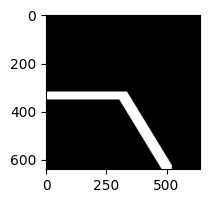


0: 256x256 l 1.00, i 0.00, c 0.00, 3.2ms
Speed: 4.6ms preprocess, 3.2ms inference, 0.0ms postprocess per image at shape (1, 3, 256, 256)
Letra detectada: l confianza: 99.75385665893555


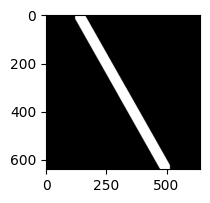


0: 256x256 i 1.00, l 0.00, c 0.00, 3.3ms
Speed: 4.5ms preprocess, 3.3ms inference, 0.0ms postprocess per image at shape (1, 3, 256, 256)
Letra detectada: i confianza: 99.99998807907104


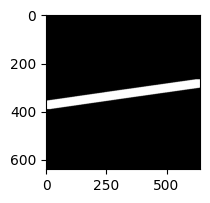


0: 256x256 i 1.00, l 0.00, c 0.00, 2.9ms
Speed: 4.6ms preprocess, 2.9ms inference, 0.0ms postprocess per image at shape (1, 3, 256, 256)
Letra detectada: i confianza: 99.99909400939941


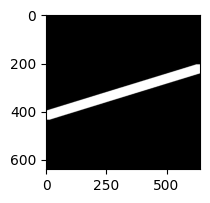


0: 256x256 i 1.00, l 0.00, c 0.00, 2.9ms
Speed: 4.4ms preprocess, 2.9ms inference, 0.0ms postprocess per image at shape (1, 3, 256, 256)
Letra detectada: i confianza: 99.99988079071045


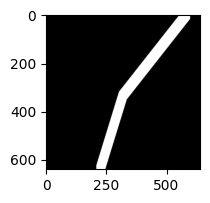


0: 256x256 i 1.00, l 0.00, c 0.00, 3.4ms
Speed: 4.8ms preprocess, 3.4ms inference, 0.0ms postprocess per image at shape (1, 3, 256, 256)
Letra detectada: i confianza: 99.99902248382568


In [88]:
for i in range(len(imgs)):
    plt.imshow(imgs[i])
    # plt.axis('off')
    # Modificar el tamaño de la imagen
    plt.gcf().set_size_inches(2, 2)
    plt.show()

    res = model(imgs[i])
    print("Letra detectada: " +  res[0].names[res[0].probs.top1] + " confianza: " + str(res[0].probs.top1conf.item() * 100))

In [56]:
res[0].probs.top1, res[0].probs.top1conf, res[0].probs.top5, res[0].probs.top5conf, res[0].names, res[0].names[res[0].probs.top1]

(2,
 tensor(0.4145, device='cuda:0'),
 [2, 1, 0],
 tensor([0.4145, 0.4089, 0.1766], device='cuda:0'),
 {0: 'c', 1: 'i', 2: 'l'},
 'l')

In [57]:
for img in imgs:
    res = model(img)
    print("Letra detectada: " +  res[0].names[res[0].probs.top1] + " confianza: " + str(res[0].probs.top1conf.item() * 100))


0: 256x256 l 0.99, i 0.01, c 0.00, 8.2ms
Speed: 12.1ms preprocess, 8.2ms inference, 0.1ms postprocess per image at shape (1, 3, 256, 256)
Letra detectada: l confianza: 99.04668927192688

0: 256x256 l 0.41, i 0.41, c 0.18, 5.0ms
Speed: 7.5ms preprocess, 5.0ms inference, 0.1ms postprocess per image at shape (1, 3, 256, 256)
Letra detectada: l confianza: 41.452571749687195

0: 256x256 i 1.00, l 0.00, c 0.00, 3.8ms
Speed: 5.8ms preprocess, 3.8ms inference, 0.1ms postprocess per image at shape (1, 3, 256, 256)
Letra detectada: i confianza: 99.99998807907104

0: 256x256 i 1.00, l 0.00, c 0.00, 5.3ms
Speed: 8.0ms preprocess, 5.3ms inference, 0.1ms postprocess per image at shape (1, 3, 256, 256)
Letra detectada: i confianza: 99.9998927116394

0: 256x256 l 0.99, i 0.01, c 0.00, 4.3ms
Speed: 6.1ms preprocess, 4.3ms inference, 0.0ms postprocess per image at shape (1, 3, 256, 256)
Letra detectada: l confianza: 98.96601438522339

0: 256x256 l 0.96, i 0.04, c 0.00, 4.6ms
Speed: 8.0ms preprocess, 4.

### Angulos

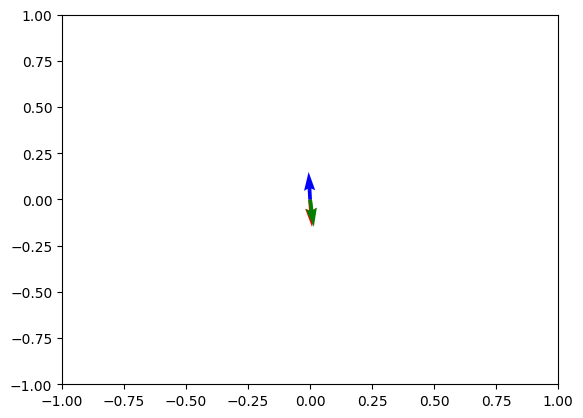

In [44]:
# graficar los vectores en un plano 2D con los valores x, y
v = [[      24.63,           0,     -7.8039], [    -9.1401,           0,     -27.035], [    -39.378,          -0,      53.321]] # Head
v = [[   0.067947,    -0.10777,    -0.99185], [    0.13127,    -0.25242,    -0.95867], [  -0.053802,    0.029403,     0.99812]] # Body
# [np.array([      24.63,           0,     -7.8039]), np.array([    -9.1401,           0,     -27.035]), np.array([    -39.378,          -0,      53.321])]

fig = plt.figure()
# 2D
ax = fig.add_subplot(111)
ax.quiver(0, 0, v[0][0], v[0][2], color='r')
ax.quiver(0, 0, v[1][0], v[1][2], color='g')
ax.quiver(0, 0, v[2][0], v[2][2], color='b')
ax.set_xlim([-1, 1])
ax.set_ylim([-1, 1])
plt.show()


In [45]:
# calcular vector promedio de v
v = np.array(v)
v_mean = np.mean(v, axis=0)
v_mean

array([ 0.04847167, -0.11026233, -0.31746667])

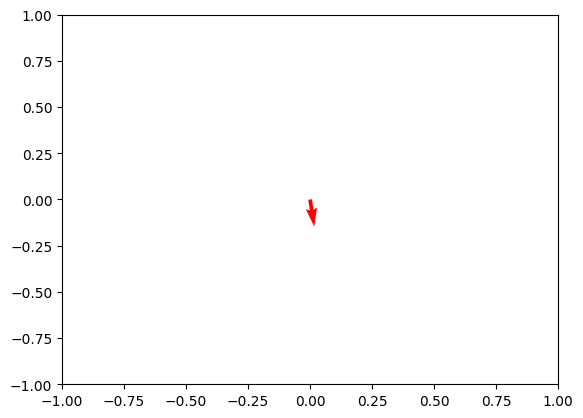

In [46]:
# graficar v_mean en 2D
fig = plt.figure()
# 2D
ax = fig.add_subplot(111)
ax.quiver(0, 0, v_mean[0], v_mean[2], color='r')
ax.set_xlim([-1, 1])
ax.set_ylim([-1, 1])
plt.show()

In [47]:
def calcular_angulo_con_eje_y(normal_plano):
  # Vector del eje X
  eje_x = np.array([-1, 0, 0])
  
  # Calcular el producto punto
  producto_punto = np.dot(normal_plano, eje_x)
  
  # Calcular las magnitudes de los vectores
  magnitud_normal_plano = np.linalg.norm(normal_plano)
  magnitud_eje_y = np.linalg.norm(eje_x)
  
  # Calcular el coseno del ángulo
  cos_theta = producto_punto / (magnitud_normal_plano * magnitud_eje_y)
  
  # Calcular el ángulo en radianes y luego convertir a grados
  angulo_radianes = np.arccos(cos_theta)
  angulo_grados = np.degrees(angulo_radianes)
  
  return angulo_grados

In [49]:
# Ejemplo de uso
normal_plano = v[0]
angulo = calcular_angulo_con_eje_y(normal_plano)

print("Ángulo con el eje Y:", angulo)  # Imprime el ángulo en grados

# Extraer las componentes X y Z del vector
componente_x = normal_plano[0]
componente_z = normal_plano[2]

print("Componente X:", componente_x)  # Imprime la componente X
print("Componente Z:", componente_z)  # Imprime la componente Z

Ángulo con el eje Y: 93.8960828619646
Componente X: 0.067947
Componente Z: -0.99185


### Para el general

In [67]:
distancias = ["300", "400"]
formas = ["C", "L", "I"]

In [76]:
for distancia in distancias:
    for forma in formas:
        path = "datasets/190824/3 PERSONAS/" + distancia + "/" + forma + "/"
        list_names = glob.glob(path + "*LEFT.jpg")
        print("list_names", list_names)
        for name in list_names:
            name_common = name.split("/")[-1][:23]

            path_img_L = path + name_common + "_LEFT.jpg"
            path_img_R = path + name_common + "_RIGHT.jpg"
            print("name_common", name_common, path_img_L, path_img_R)


for forma in formas:
    list_names = glob.glob("datasets/190824/4 PERSONAS/400/" + forma + "/*T.jpg")
    name_common = list_names[0].split("/")[-1][:23]
    print("name_common", name_common)

list_names ['datasets/190824/3 PERSONAS/300/C/11_59_26_19_08_2024_IMG_LEFT.jpg', 'datasets/190824/3 PERSONAS/300/C/11_59_40_19_08_2024_IMG_LEFT.jpg', 'datasets/190824/3 PERSONAS/300/C/11_59_45_19_08_2024_IMG_LEFT.jpg', 'datasets/190824/3 PERSONAS/300/C/11_59_16_19_08_2024_IMG_LEFT.jpg', 'datasets/190824/3 PERSONAS/300/C/11_59_54_19_08_2024_IMG_LEFT.jpg']
name_common 11_59_26_19_08_2024_IMG datasets/190824/3 PERSONAS/300/C/11_59_26_19_08_2024_IMG_LEFT.jpg datasets/190824/3 PERSONAS/300/C/11_59_26_19_08_2024_IMG_RIGHT.jpg
name_common 11_59_40_19_08_2024_IMG datasets/190824/3 PERSONAS/300/C/11_59_40_19_08_2024_IMG_LEFT.jpg datasets/190824/3 PERSONAS/300/C/11_59_40_19_08_2024_IMG_RIGHT.jpg
name_common 11_59_45_19_08_2024_IMG datasets/190824/3 PERSONAS/300/C/11_59_45_19_08_2024_IMG_LEFT.jpg datasets/190824/3 PERSONAS/300/C/11_59_45_19_08_2024_IMG_RIGHT.jpg
name_common 11_59_16_19_08_2024_IMG datasets/190824/3 PERSONAS/300/C/11_59_16_19_08_2024_IMG_LEFT.jpg datasets/190824/3 PERSONAS/300/C/1

In [56]:
angulos = ["0", "10", "20", "30", "40", "50", "60", "70", "80", "90", "100", "110", "120", "130", "140", "150", "160", "170", "180"]

for distancia in distancias:
    for angulo in angulos:
        list_names = glob.glob("datasets/190824/ANGULOS/" + distancia + "/" + angulo + "/*T.jpg")
        print("name_common", list_names[0].split("/")[-1][:23])
        

name_common 13_39_44_19_08_2024_IMG
name_common 13_40_42_19_08_2024_IMG
name_common 13_41_04_19_08_2024_IMG
name_common 13_41_33_19_08_2024_IMG
name_common 13_42_01_19_08_2024_IMG
name_common 13_42_23_19_08_2024_IMG
name_common 13_42_44_19_08_2024_IMG
name_common 13_43_04_19_08_2024_IMG
name_common 13_43_47_19_08_2024_IMG
name_common 13_44_04_19_08_2024_IMG
name_common 13_44_25_19_08_2024_IMG
name_common 13_44_46_19_08_2024_IMG
name_common 13_45_11_19_08_2024_IMG
name_common 14_09_01_19_08_2024_IMG
name_common 14_09_22_19_08_2024_IMG
name_common 14_09_42_19_08_2024_IMG
name_common 14_10_14_19_08_2024_IMG
name_common 14_10_37_19_08_2024_IMG
name_common 14_10_56_19_08_2024_IMG
name_common 14_13_27_19_08_2024_IMG
name_common 14_13_54_19_08_2024_IMG
name_common 14_14_15_19_08_2024_IMG
name_common 14_14_49_19_08_2024_IMG
name_common 14_15_21_19_08_2024_IMG
name_common 14_15_43_19_08_2024_IMG
name_common 14_16_08_19_08_2024_IMG
name_common 14_16_38_19_08_2024_IMG
name_common 14_17_04_19_08_2

In [63]:
distancias_all = ["200", "250","300","350", "400", "450", "500", "550", "600"]
for distancia in distancias_all:
    list_names = glob.glob("datasets/190824/Profundidades/" + distancia + "/*T.jpg")
    print("name_common", list_names[0].split("/")[-1][:23])

name_common 14_22_52_19_08_2024_IMG
name_common 14_23_33_19_08_2024_IMG
name_common 14_24_25_19_08_2024_IMG
name_common 14_24_52_19_08_2024_IMG
name_common 14_25_33_19_08_2024_IMG
name_common 14_26_10_19_08_2024_IMG
name_common 14_26_36_19_08_2024_IMG
name_common 14_26_58_19_08_2024_IMG
name_common 14_27_14_19_08_2024_IMG


### Hull

In [13]:
list_centroides = np.array([[     12.906,     -5.6716,      325.04], [    -84.022,     0.51156,      323.71], [      70.97,      -8.224,      234.19]])
# I 4 personas
list_centroides = np.array([[-60.347764176796, -3.9895528734680283, 392.65137437520553], [101.13981171199478, 3.144458126190732, 414.0616904725735], [29.924939360861327, -3.2556900596185194, 398.18851764504336], [-145.27083144918882,  -2.6295289001328976, 387.81273939946743]])
list_centroides = np.array([[-52.16309054453149, -4.384728105946059, 391.1344645234868], [38.77345695124703, -2.26010745091458, 392.2968368956842], [113.85823660932037, 1.818539837867501, 395.4663406940613], [-132.6410352179658, 0.12461937105346088, 387.6726789974258]])
# C 4 personas
# list_centroides = np.array([[-62.89662585235389, -4.244539765609056, 395.6929313342588], [-152.65559773092852, -1.116229748931671,  309.2238178977691], [36.97537186156347, -3.01008999724177, 382.5338752083111], [90.40059043138935, -4.564430817789882, 312.66217545792256]])
# list_centroides = np.array([[    -109.02,     -7.6323,      264.16],
#        [     24.457,      15.242,      457.61],
#        [    -72.686,      10.415,      476.51],
#        [     68.539,      1.6482,      231.03]])


centroide_tmp = np.array([  -0.048378,     -4.4613,      294.31])[[0, 2]]
centroide_tmp = np.array([-18.638461138282178, -1.6825784267571784, 398.17858047307243])[[0, 2]]
centroide_tmp = np.array([-8.043108050482473, -1.1754190869849193, 391.6425802776645])[[0, 2]]
# centroide_tmp = np.array([-22.044065322582394, -3.2338225823930946, 350.0281999745654])[[0, 2]]
# centroide_tmp = np.array([    -22.177,      4.9182,      357.33])[[0, 2]]

avg_normal_tmp = np.array([   -0.10239,   -0.063222,    -0.99273])[[0, 2]]
avg_normal_tmp = np.array([-0.008791280175760096, -0.06316180010548747, -0.9979645787302803])[[0, 2]]
avg_normal_tmp = np.array([0.07352600043371224, -0.07850698984664584, -0.994198460975192])[[0, 2]]
# avg_normal_tmp = np.array([-0.9466273703669277, -0.32055629970791966, -0.033768037991010316])[[0, 2]]
# avg_normal_tmp = np.array([    0.24061,   -0.037942,    -0.96988])[[0, 2]]

In [14]:
# Función para calcular la intersección de dos segmentos
def line_intersection(p1, p2, q1, q2):
    # p1, p2 son los puntos del segmento del polígono
    # q1, q2 son los puntos del segmento del vector
    A1 = p2[1] - p1[1]
    B1 = p1[0] - p2[0]
    C1 = A1 * p1[0] + B1 * p1[1]

    A2 = q2[1] - q1[1]
    B2 = q1[0] - q2[0]
    C2 = A2 * q1[0] + B2 * q1[1]

    det = A1 * B2 - A2 * B1
    if det == 0:
        return None  # Las líneas son paralelas

    x = (B2 * C1 - B1 * C2) / det
    y = (A1 * C2 - A2 * C1) / det

    # Verificar si la intersección está dentro de los segmentos
    if (min(p1[0], p2[0]) <= x <= max(p1[0], p2[0]) and
        min(p1[1], p2[1]) <= y <= max(p1[1], p2[1]) and
        min(q1[0], q2[0]) <= x <= max(q1[0], q2[0]) and
        min(q1[1], q2[1]) <= y <= max(q1[1], q2[1])):
        return np.array([x, y])
    return None

In [15]:
puntos = list_centroides[:,[0,2]]
# puntos = np.array([[     -12.906,      325.04],
#        [    -84.022,      323.71],
#        [      70.97,      290.19],
#        [      20.97,      234.19]])

val_dif_mayor_menor = 0
list_pos_extremo = []
list_union_centroides = []

if len(puntos) > 2:
    # INTERSEPTO --------------------------------------------------------------------------------------------------------
    puntos_sorted = puntos[np.argsort(puntos[:, 1])]
    pt_menor = puntos_sorted[0, 1]
    pt_mayor = puntos_sorted[-1, 1]
    val_dif_mayor_menor = pt_mayor - pt_menor
    if val_dif_mayor_menor <= 30: 
        for i in range(len(puntos_sorted) - 1):
            index = np.where(puntos == puntos_sorted[i])[0][0]
            index_2 = np.where(puntos == puntos_sorted[i+1])[0][0]
            list_union_centroides.append([index, index_2])
        list_pos_extremo.append([np.where(puntos == puntos_sorted[0])[0][0], np.where(puntos == puntos_sorted[-1])[0][0]])
    else:
        # Calcular la envolvente convexa
        hull = ConvexHull(puntos)

        # Calcular el punto final del vector
        vector_end = centroide_tmp + avg_normal_tmp * 1000  # Escalar para que sea largo

        for simplex in hull.simplices:
            p1, p2 = puntos[simplex]
            interseccion = line_intersection(p1, p2, centroide_tmp, vector_end)
            if interseccion is None:
                print("No hay intersección", simplex, p1, p2)
                list_union_centroides.append(simplex)
            else:
                print(simplex, "p1:", p1, "p2:", p2, "intersección:", interseccion)
                list_pos_extremo.append(simplex)
    # --------------------------------------------------------------------------------------------------------------------

    # # DISTANCIA --------------------------------------------------------------------------------------------------------
    # # Inicializar variables para la distancia máxima y los puntos correspondientes
    # hull = ConvexHull(puntos)
    # max_distancia = 0
    # puntos_max_distancia = None
    # positions = (0, 0)

    # # Iterar sobre cada par de índices en hull_simplices
    # for simplex in hull.simplices:
    #     p1, p2 = puntos[simplex]
    #     print("p1:", p1, "p2:", p2)
    #     distancia = np.linalg.norm(p2 - p1)
    #     # distancia en  perspectiva x
    #     distancia = np.linalg.norm(p2[0] - p1[0])
    #     if distancia > max_distancia:
    #         print(distancia, p1, p2)
    #         max_distancia = distancia
    #         puntos_max_distancia = (p1, p2)
    #         list_pos_extremo = [simplex]

    # for simplex in hull.simplices:
    #     if not np.array_equal(simplex, list_pos_extremo[0]):
    #         list_union_centroides.append(simplex)
    # # --------------------------------------------------------------------------------------------------------------------
else:
    list_union_centroides = [[0, 1]]


p1 [    -132.64      387.67] p2 [    -52.163      391.13]
p1 [    -52.163      391.13] p2 [     38.773       392.3]
p1 [     38.773       392.3] p2 [     113.86      395.47]


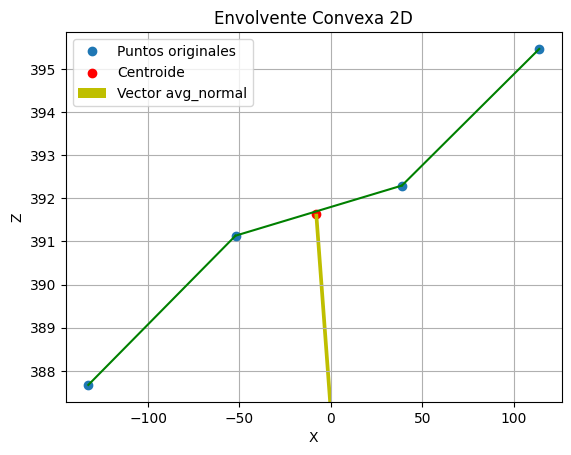

In [16]:
plt.figure()

plt.plot(puntos[:, 0], puntos[:, 1], 'o', label='Puntos originales')

for simplex in list_union_centroides:
  p1, p2 = puntos[simplex]
  # p1_3D, p2_3D = list_centroides[simplex]
  print("p1", p1, "p2", p2)
  # print("p1_3D", p1_3D, "p2_3D", p2_3D)
  plt.plot(puntos[simplex, 0], puntos[simplex, 1], 'g-')

# Graficar el punto centroide
plt.scatter(centroide_tmp[0], centroide_tmp[1], c='r', label='Centroide')

# Graficar el vector avg_normal
plt.quiver(centroide_tmp[0], centroide_tmp[1], avg_normal_tmp[0], avg_normal_tmp[1], scale=2, color='y', label='Vector avg_normal')


plt.xlabel('X')
plt.ylabel('Z')
plt.title('Envolvente Convexa 2D')
plt.legend()
plt.grid(True)
plt.show()

In [17]:
# plt.imshow(img_res_2)

In [18]:
# [((388, 325), (316, 323)),
#   ((388, 325), (470, 290)),
#   ((420, 234), (470, 290))]
def draw_line_with_conditions(image, pt1, pt2, mean_x, val_f):
    x1, y1 = pt1
    x2, y2 = pt2
    _, width = image.shape[:2]
    x_2 = 0

    start, end = (0, 0), (1, 0)
    # Determinar la dirección de la línea
    if x1 < mean_x and x1 < x2 and val_f:
        start, end = (x2, y2), (x1, y1)
        x_2 = 0
        val_f = False
    elif x2 < mean_x and x2 < x1 and val_f:
        start, end = (x1, y1), (x2, y2)
        x_2 = 0
        val_f = False
    elif x1 > mean_x and x1 > x2:
        start, end = (x2, y2), (x1, y1)
        x_2 = width-1
    elif x2 > mean_x and x2 > x1:
        start, end = (x1, y1), (x2, y2)
        x_2 = width-1
    else:
        print("Error en la dirección de la línea")
    
    # Calcular la pendiente y el intercepto
    # y = m x + b
    m = (end[1] - start[1]) / (end[0] - start[0])
    b = start[1] - m * start[0]
    # print("m", m, "b", b)
    
    y_res = int(m * x_2 + b)

    cv2.line(image, start, (x_2, y_res), (0, 0, 0), 2)

    return val_f

In [19]:
big_size = 800
re_size = 640
half_re_size = re_size//2
# generar la imagen hasta el limite maximo
img = np.ones((big_size, big_size, 3), dtype=np.uint8) * 255

list_points = []
mean_x = int(centroide_tmp[0]) + 400
mean_y = int(centroide_tmp[1])
list_inf = []


for simplex in list_union_centroides:
    pos0 = simplex[0]
    pos1 = simplex[1]
    p1, p2 = puntos[simplex]
    list_points.append(((int(p1[0])+400, int(p1[1])), (int(p2[0])+400, int(p2[1]))))

    if pos0 in list_pos_extremo[0] or pos1 in list_pos_extremo[0]:
        if pos0 in list_pos_extremo[0] and not pos1 in list_pos_extremo[0]:
            p1 = puntos[pos1]
            p2 = puntos[pos0]
        elif pos1 in list_pos_extremo[0] and not pos0 in list_pos_extremo[0]:
            p1 = puntos[pos0]
            p2 = puntos[pos1]
        list_inf.append(((int(p1[0])+400, int(p1[1])), (int(p2[0])+400, int(p2[1]))))
        print("simplex", simplex)
print("list_inf", list_inf)


simplex [3, 0]
simplex [1, 2]
list_inf [((348, 391), (268, 387)), ((438, 392), (513, 395))]


In [20]:
# unir los puntos de list_points en la imagen img
for points in list_points:
    cv2.line(img, points[0], points[1], (0, 0, 0), 2)

In [21]:
for points in sorted(list_inf, key=lambda x: x[1][0]):
    x1, y1 = points[0]
    x2, y2 = points[1]
    print(x1, y1, x2, y2)

    m = (y2 - y1) / (x2 - x1)

    if x1 - x2 != 0 and y1 - y2 != 0:
        arrow_left =  x1 > x2
        if arrow_left:
            x = 0
            b = int(y1 - m * x1)
            cv2.line(img, points[0], [x, b], (0, 0, 0), 2)
            print("arrow_left", x, b)
        else:
            x = big_size-1
            b = int(y2 - m * x2)
            y = int(m * x + b)
            cv2.line(img, points[0], [x, y], (0, 0, 0), 2)
            print("arrow_right", x, y)
    elif y1 - y2 == 0 and x1 - x2 != 0:
        arrow_left =  x1 > x2
        if arrow_left:
            cv2.line(img, points[0], [0, y1], (0, 0, 0), 2)
        else:
            cv2.line(img, points[0], [big_size-1, y2], (0, 0, 0), 2)
    elif x1 - x2 == 0 and y1 - y2 != 0:
        if y1 > y2:
            cv2.line(img, points[0], [x1, 0], (0, 0, 0), 2)
        else:
            cv2.line(img, points[0], [x2, big_size-1], (0, 0, 0), 2)

348 391 268 387
arrow_left 0 373
438 392 513 395
arrow_right 799 405


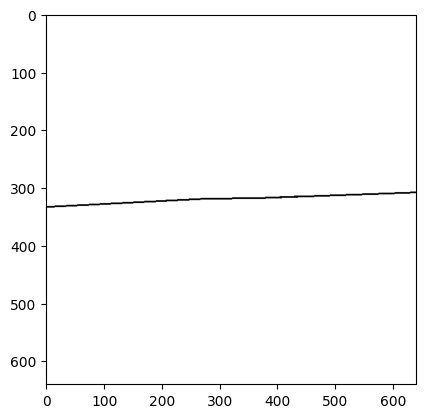

In [22]:

# # proyectar una linea que pase por dos puntos hacia el infinito
# for points in list_inf:
#     cv2.line(img, points[0], points[1], (0, 0, 0), 2)

if mean_y-half_re_size < 0:
    img_crop = img[:re_size, :]
elif mean_y+half_re_size > big_size:
    img_crop = img[big_size-re_size:, :]
else:
    img_crop = img[mean_y-half_re_size:mean_y+half_re_size, :]

if mean_x-half_re_size < 0:
    img_crop = img_crop[:, :re_size]
elif mean_x+half_re_size > big_size:
    img_crop = img_crop[:, big_size-re_size:]
else:
    img_crop = img_crop[:, mean_x-half_re_size:mean_x+half_re_size]

img_crop = cv2.flip(img_crop, 0)
plt.imshow(img_crop)

# img_res = cv2.erode(img_crop, cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3)), iterations=15) # _thick
# img_res_2 = cv2.bitwise_not(img_res) # _not_thick
# plt.imshow(img_res_2)

### Vectores de la cabeza

In [79]:
points_head = np.array([[     -98.85189411323914, -68.16624156022395, 270.01665432159876], [    -97.54063524349037, -74.2152464264587, 278.0844041100571], [    -104.20939076852582, -73.29113784423787, 272.17247958481903]])
centroid = np.array([-109.01752326183745, -7.632308045356632, 264.1612460732829])

In [80]:
# graficar los vectores en un plano 2D con los valores x, z
v1 = points_head[:, [0,2]]
v0 = centroid[[0,2]]

v0, v1

(array([    -109.02,      264.16]),
 array([[    -98.852,      270.02],
        [    -97.541,      278.08],
        [    -104.21,      272.17]]))

In [81]:
# calcular el vector de un punto a otro
vectores = v1 - v0
vectores 

array([[     10.166,      5.8554],
       [     11.477,      13.923],
       [     4.8081,      8.0112]])

In [82]:
# promedio de los 3 vectores
avg_normal = np.mean(vectores, axis=0)
avg_normal

array([     8.8169,      9.2633])

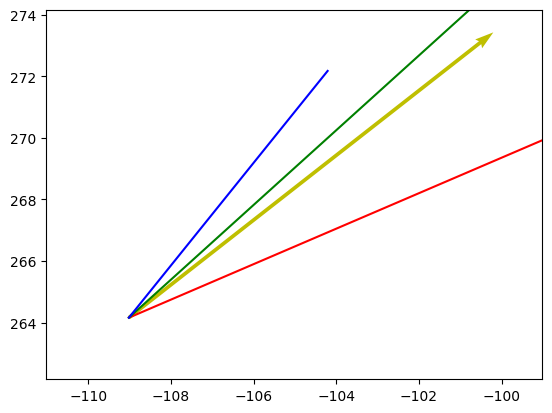

In [84]:
fig = plt.figure()
# 2D
ax = fig.add_subplot(111)
# linea 
ax.plot([v0[0], v1[0,0]], [v0[1], v1[0,1]], 'r')
ax.plot([v0[0], v1[1,0]], [v0[1], v1[1,1]], 'g')
ax.plot([v0[0], v1[2,0]], [v0[1], v1[2,1]], 'b')

# graficar vector promedio con magnitud variable
ax.quiver(v0[0], v0[1], avg_normal[0], avg_normal[1], color='y', angles='xy', scale_units='xy', scale=1)


# Configurar los límites del gráfico
# ax.set_xlim([-200, 200])
# ax.set_ylim([0, 500])
ax.set_xlim([-150, -50])
ax.set_ylim([250, 300])
ax.set_xlim(v0[0] - 2, v0[0] + 10)
ax.set_ylim(v0[1] - 2, v0[1] + 10)

plt.show()


In [87]:
v1, v1[0,0], v1[1,0], v1[2,0]

(array([[    -98.852,      270.02],
        [    -97.541,      278.08],
        [    -104.21,      272.17]]),
 -98.85189411323914,
 -97.54063524349037,
 -104.20939076852582)

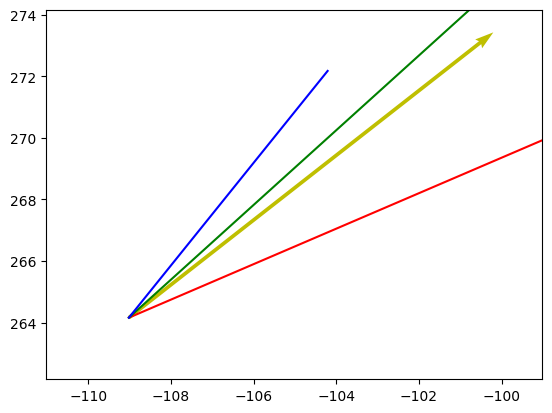

In [89]:
vectores_2 = points_head - centroid
avg_normal_2 = np.mean(vectores_2, axis=0)

fig = plt.figure()
# 2D
ax = fig.add_subplot(111)
# linea 
ax.plot([centroid[0], points_head[0,0]], [centroid[2], points_head[0,2]], 'r')
ax.plot([centroid[0], points_head[1,0]], [centroid[2], points_head[1,2]], 'g')
ax.plot([centroid[0], points_head[2,0]], [centroid[2], points_head[2,2]], 'b')

# graficar vector promedio con magnitud variable
ax.quiver(centroid[0], centroid[2], avg_normal_2[0], avg_normal_2[2], color='y', angles='xy', scale_units='xy', scale=1)


# ax.quiver(v0[0], v0[1], v1[0,0], v1[0,1], color='r')
# ax.quiver(v0[0], v0[1], v1[1,0], v1[1,1], color='g')
# ax.quiver(v0[0], v0[1], v1[2,0], v1[2,1], color='b')


# Configurar los límites del gráfico
# ax.set_xlim([-200, 200])
# ax.set_ylim([0, 500])
ax.set_xlim([-150, -50])
ax.set_ylim([250, 300])
ax.set_xlim(centroid[0] - 2, centroid[0] + 10)
ax.set_ylim(centroid[2] - 2, centroid[2] + 10)

plt.show()

# Grafica para corrobar direccion de vectores

In [4]:
v1 = np.array([np.array([    -11.922,          -0,     -14.396]), np.array([    -9.7026,          -0,     -13.835])])
v2 = [[17.27680635028759, -55.47532697043327, 297.04149784196085], [15.057851684126522, -58.811167303735104, 296.4809162691095]]
centroid = np.array([     5.3552,     -3.6252,      282.65])

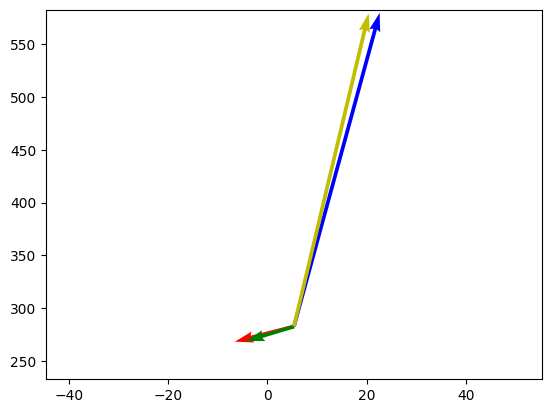

In [13]:
fig = plt.figure()
# 2D
ax = fig.add_subplot(111)

# graficar vector promedio con magnitud variable
ax.quiver(centroid[0], centroid[2], v1[0][0], v1[0][2], color='r', angles='xy', scale_units='xy', scale=1)
ax.quiver(centroid[0], centroid[2], v1[1][0], v1[1][2], color='g', angles='xy', scale_units='xy', scale=1)
ax.quiver(centroid[0], centroid[2], v2[0][0], v2[0][2], color='b', angles='xy', scale_units='xy', scale=1)
ax.quiver(centroid[0], centroid[2], v2[1][0], v2[1][2], color='y', angles='xy', scale_units='xy', scale=1)


# ax.quiver(v0[0], v0[1], v1[0,0], v1[0,1], color='r')
# ax.quiver(v0[0], v0[1], v1[1,0], v1[1,1], color='g')
# ax.quiver(v0[0], v0[1], v1[2,0], v1[2,1], color='b')


# Configurar los límites del gráfico
# ax.set_xlim([-200, 200])
# ax.set_ylim([0, 500])
ax.set_xlim([-150, -50])
ax.set_ylim([250, 300])
ax.set_xlim(centroid[0] - 50, centroid[0] + 50)
ax.set_ylim(centroid[2] - 50, centroid[2] + 300)

plt.show()

In [14]:
def get_invest_direction(vector):
  return -vector

def is_same_side_vector(v, normal_plano):
  # Calculamos el producto punto entre el vector y el vector normal del plano
  producto_punto = np.dot(v, normal_plano)
  
  # Si el producto punto es positivo, están en el mismo lado del plano
  return producto_punto > 0

def get_vector_normal_to_head(vector, vector_normal):
    if is_same_side_vector(vector, vector_normal):
        return vector, False
    return get_invest_direction(vector), True

In [ ]:
get_vector_normal_to_head(v2)

# Grupo con keypoints

In [2]:
keypoints = [np.array([[    -101.08,     -71.563,      277.18],
       [    -98.427,     -76.795,      281.53],
       [    -105.01,     -75.698,      275.06],
       [    -520.91,     -287.36,      542.82],
       [    -116.56,     -74.084,      275.57],
       [    -105.51,     -44.173,      288.21],
       [    -123.33,     -45.797,      261.37],
       [    -104.27,     -6.9012,      268.34],
       [    -133.79,     -17.095,      250.25],
       [    -96.379,      16.775,      285.34],
       [    -114.01,      10.579,      257.66],
       [    -101.55,      26.452,       272.7],
       [    -114.91,      25.602,      260.48],
       [    -108.19,      81.699,      277.37],
       [    -116.47,      81.066,      262.21],
       [    -113.01,      130.77,      272.49],
       [    -120.18,      135.47,      264.36]]), np.array([[     23.018,     -46.843,      416.13],
       [     26.953,     -50.811,      416.77],
       [     19.635,     -50.944,       417.9],
       [     33.723,     -47.287,      420.22],
       [     15.013,     -47.099,      422.53],
       [     44.794,     -19.462,      413.28],
       [     4.0344,     -19.898,      422.86],
       [     53.652,      14.322,      408.54],
       [     -5.165,      12.532,      420.13],
       [     39.481,       37.56,      407.05],
       [    -2.1088,      37.886,      420.52],
       [     34.005,      41.834,      407.45],
       [     7.3573,       41.82,      411.63],
       [     36.748,      87.824,      414.72],
       [     5.2887,      87.976,      417.58],
       [     37.217,      134.52,      415.15],
       [       10.6,      135.69,      421.67]]), np.array([[    -60.166,     -51.169,      419.81],
       [    -57.234,     -55.653,      420.76],
       [    -64.483,     -55.054,      419.49],
       [    -88.851,     -90.637,      729.35],
       [    -73.328,     -53.279,       422.8],
       [    -44.996,     -27.782,       429.5],
       [    -84.469,     -26.833,      421.32],
       [    -38.154,      7.0595,         433],
       [    -92.804,       7.314,      421.38],
       [    -44.375,      31.098,      423.37],
       [    -80.755,      29.678,      415.54],
       [    -50.572,      40.451,       419.9],
       [    -75.692,      40.313,       413.8],
       [    -52.651,        90.2,      426.33],
       [    -78.088,      88.772,      415.14],
       [    -54.099,         137,       427.3],
       [    -75.576,      132.71,      410.73]]), np.array([[     60.793,     -61.919,      267.93],
       [     63.352,     -63.617,      260.56],
       [    -520.91,     -287.36,      542.82],
       [     75.882,     -58.811,      254.99],
       [    -520.91,     -287.36,      542.82],
       [      79.31,     -30.753,      235.89],
       [      68.04,     -32.358,      244.72],
       [     78.211,      -0.318,       230.1],
       [    -520.91,     -287.36,      542.82],
       [     63.476,      26.259,      228.27],
       [    -520.91,     -287.36,      542.82],
       [     73.365,      32.347,      239.71],
       [     61.639,      29.719,      230.66],
       [     71.086,      82.792,      237.07],
       [     65.677,      88.678,      266.96],
       [     81.456,      129.64,       236.3],
       [     72.304,      136.18,      265.24]])]

In [180]:
keypoints = np.array([
    np.array([[    -15.632,     -14.256,      285.63],
       [    -11.753,     -17.636,      286.73],
       [    -19.316,      -17.63,      286.63],
       [    -7.0229,     -15.466,      291.67],
       [    -26.735,     -16.156,       299.1],
       [        1.6,      3.3062,      292.99],
       [    -38.069,      3.3159,       293.9],
       [     7.2612,      29.624,      284.33],
       [    -45.549,      27.861,         288],
       [    -8.6475,      35.266,      274.01],
       [    -26.092,      29.813,      274.53],
       [     -5.556,      46.814,       279.2],
       [    -33.769,      47.349,       280.7],
       [     2.2513,      60.995,      259.44],
       [    -42.765,      64.794,      263.94],
       [   -0.23254,      98.209,      266.73],
       [    -52.927,      110.59,      283.32]]), 
       np.array([[      70.18,     -14.042,      258.09],
       [     73.665,      -18.13,      257.81],
       [     66.939,     -17.136,       259.4],
       [     83.372,     -15.729,      263.71],
       [     65.078,     -12.802,      260.84],
       [     92.245,      7.1944,      253.74],
       [     69.259,      7.0062,      279.78],
       [     87.853,      34.871,      239.49],
       [      58.34,      34.453,      276.94],
       [     65.431,      38.254,      241.65],
       [     45.481,       39.36,      243.84],
       [     77.836,      52.093,      242.66],
       [     60.293,       49.47,      250.75],
       [      53.03,      63.068,      233.03],
       [     32.029,      60.589,      255.18],
       [     51.631,      107.07,      237.12],
       [     28.578,       103.2,      253.32]]), 
       np.array([[    -87.713,     -5.0139,      258.39],
       [    -85.264,      -9.127,      258.45],
       [    -91.378,     -9.0264,      255.44],
       [    -391.26,     -215.84,      404.14],
       [    -101.44,     -7.3618,      254.06],
       [    -78.773,      10.045,      265.61],
       [    -115.13,      11.086,      250.18],
       [    -66.084,      34.875,      257.42],
       [     -115.9,      36.116,      235.75],
       [    -72.833,      37.338,      233.85],
       [    -93.537,      40.112,       232.5],
       [    -78.831,       52.05,      238.68],
       [    -83.763,      42.209,      183.12],
       [    -47.205,       58.21,      230.38],
       [    -91.458,      62.251,      225.11],
       [    -60.842,      103.79,         239],
       [     -94.14,      93.624,      198.02]]), 
       np.array([[    -105.77,     -11.827,      180.85],
       [    -391.26,     -215.84,      404.14],
       [    -106.47,     -15.888,      175.46],
       [    -391.26,     -215.84,      404.14],
       [    -116.64,     -13.215,       170.1],
       [    -124.55,      9.3129,      188.41],
       [    -128.23,      7.4001,      154.13],
       [    -115.87,      40.905,       199.1],
       [    -123.93,      39.123,      148.05],
       [      -85.7,      39.606,         183],
       [    -96.946,      43.684,      166.24],
       [    -118.71,      52.193,      155.54],
       [     -130.7,      54.606,      151.46],
       [    -86.655,      58.536,       195.4],
       [    -86.916,       54.64,      167.67],
       [    -88.074,       91.46,      158.11],
       [     -88.74,      93.856,      158.06]]), 
       np.array([[     287.49,     -51.389,      369.33],
       [      291.1,     -54.499,      369.52],
       [     285.39,     -54.976,      370.15],
       [     298.79,     -52.131,      371.98],
       [     283.09,     -53.096,      373.35],
       [     300.81,     -29.294,      362.82],
       [     277.94,     -32.157,      379.31],
       [     303.83,    -0.85673,      357.23],
       [     269.12,     -6.0651,       380.3],
       [     290.79,      20.003,      356.32],
       [     264.19,      17.347,      380.65],
       [     285.21,      23.822,       357.8],
       [      271.1,      23.455,      370.17],
       [      294.9,      63.428,      362.05],
       [     271.37,      64.066,      372.76],
       [      292.3,      97.359,      353.07],
       [     275.03,      101.36,      374.08]]), 
       np.array([[     316.32,      -55.08,      329.76],
       [     320.42,     -58.656,      330.46],
       [     312.26,     -57.993,      330.64],
       [     349.71,     -60.326,      355.58],
       [     308.57,     -55.456,       334.3],
       [     328.81,     -32.202,      325.51],
       [     306.66,     -31.739,      339.38],
       [     330.56,     -7.1329,         319],
       [     304.18,     -7.3249,      344.85],
       [     325.47,      15.275,      318.25],
       [     301.21,      16.016,      342.19],
       [     319.12,      23.059,      319.66],
       [     307.16,      24.518,      330.75],
       [     321.17,      62.409,      318.31],
       [     313.26,      65.583,      335.23],
       [     323.03,      100.16,      317.12],
       [     314.75,      106.12,      333.39]]), 
       np.array([[     227.33,     -46.994,      387.81],
       [     230.31,     -49.943,      388.78],
       [     224.26,     -50.668,      388.11],
       [    -391.26,     -215.84,      404.14],
       [     217.61,     -49.285,      390.03],
       [     235.15,     -28.359,      392.95],
       [      208.7,     -30.253,       390.9],
       [     238.05,      -4.221,      393.71],
       [     185.73,     -6.0952,      357.92],
       [     237.94,     -1.7601,      393.53],
       [     211.51,     -4.5542,      386.94],
       [     231.51,      19.867,      391.59],
       [     213.57,      19.277,       387.8],
       [     229.99,      58.452,      396.17],
       [     216.32,      57.588,      392.97],
       [     228.11,      94.932,      398.75],
       [     213.97,      93.116,      390.84]])])

In [4]:
def remove_outliers(points, factor=1.5):
  """
  Remove outliers from a set of 2D points using the IQR method.
  
  :param points: numpy array of shape (n, 2) where n is the number of points
  :param factor: IQR factor, default is 1.5
  :return: numpy array with outliers removed
  """
  # Separate x and y coordinates
  x = points[:, 0]
  y = points[:, 1]
  
  # Calculate Q1, Q3, and IQR for both x and y
  Q1_x, Q3_x = np.percentile(x, [25, 75])
  Q1_y, Q3_y = np.percentile(y, [25, 75])
  IQR_x = Q3_x - Q1_x
  IQR_y = Q3_y - Q1_y
  
  # Calculate the outlier range
  lower_bound_x = Q1_x - factor * IQR_x
  upper_bound_x = Q3_x + factor * IQR_x
  lower_bound_y = Q1_y - factor * IQR_y
  upper_bound_y = Q3_y + factor * IQR_y
  
  # Create a mask for non-outlier points
  mask = ((x >= lower_bound_x) & (x <= upper_bound_x) &
          (y >= lower_bound_y) & (y <= upper_bound_y))
  
  # Return the filtered points
  return points[mask]

In [5]:
def get_roi(person):

    person = remove_outliers(person)

    # reordenar los puntos de la persona de menor a mayor en x
    sort_x = person[np.argsort(person[:, 0])]
    sort_y = person[np.argsort(person[:, 1])]

    x_less = sort_x[0][0] - 50
    y_less = sort_y[0][1] - 50
    x_more = sort_x[-1][0] + 50
    y_more = sort_y[-1][1] + 50

    return x_less, y_less, x_more, y_more

In [6]:
def is_intercept(area1, area2):
    # intercepcion de area
    x1_1, y1_1, x2_1, y2_1 = area1
    x1_2, y1_2, x2_2, y2_2 = area2

    if x1_1 < x2_2 and x2_1 > x1_2 and y1_1 < y2_2 and y2_1 > y1_2:
        return True
    return False


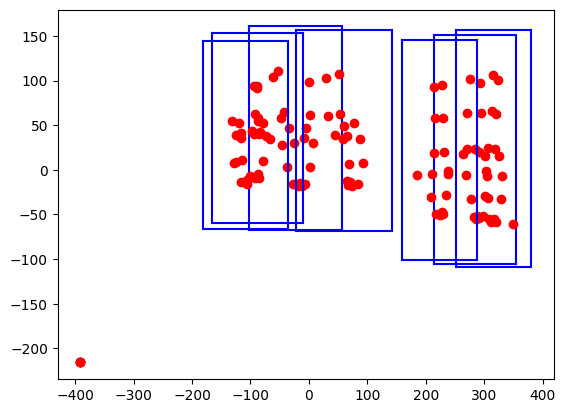

In [7]:
# graficar cada punto de keypoints en 2D xy 
fig = plt.figure()
# 2D

ax = fig.add_subplot(111)
list_areas = []

for person in keypoints:
    x_less, y_less, x_more, y_more = get_roi(person)
    list_areas.append([x_less, y_less, x_more, y_more])
    # punto
    ax.plot(person[:, 0], person[:, 1], 'ro')
    # linea
    ax.plot([x_less, x_more], [y_less, y_less], 'b')  # Bottom edge
    ax.plot([x_less, x_more], [y_more, y_more], 'b')  # Top edge
    ax.plot([x_less, x_less], [y_less, y_more], 'b')  # Left edge
    ax.plot([x_more, x_more], [y_less, y_more], 'b')  # Right edge


# Configurar los límites del gráfico
# ax.set_xlim([-350, 350])
# ax.set_ylim([-300, 300])

plt.show()

In [8]:
for i in range(len(list_areas)):
    for j in range(i+1, len(list_areas)):
        if is_intercept(list_areas[i], list_areas[j]):
            print("Intercepta", i, j)
        else:
            print("No intercepta", i, j)

Intercepta 0 1
Intercepta 0 2
Intercepta 0 3
No intercepta 0 4
No intercepta 0 5
No intercepta 0 6
Intercepta 1 2
No intercepta 1 3
No intercepta 1 4
No intercepta 1 5
No intercepta 1 6
Intercepta 2 3
No intercepta 2 4
No intercepta 2 5
No intercepta 2 6
No intercepta 3 4
No intercepta 3 5
No intercepta 3 6
Intercepta 4 5
Intercepta 4 6
Intercepta 5 6


# Grupo con centroides

In [3]:
import math

def calcular_distancia_minima_a_cada_punto(puntos):
  distancias_minimas = []
  
  for i in range(len(puntos)):
      distancia_minima = float('inf')
      punto_min = None
      
      for j in range(len(puntos)):
          if i != j:
              x1, y1 = puntos[i]
              x2, y2 = puntos[j]
              distancia = math.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2)
              
              if distancia < distancia_minima:
                  distancia_minima = distancia
                  punto_min = puntos[j]
      
      distancias_minimas.append((puntos[i], distancia_minima, punto_min))
  
  return distancias_minimas

In [4]:
list_centroides_2D = [
    np.array([
        [     1035.4,       513.2],
        [     784.71,         495],
        [     641.81,      486.32],
        [     1234.1,      511.95],
        [      315.7,      458.74],
        [     1347.2,       503.8],
        [     459.38,      512.63]]), 
    np.array([
        [     780.26,      494.92],
        [     1036.1,       513.5],
        [     1234.2,      512.58],
        [     1352.3,      503.39],
        [     314.05,      457.03],
        [     641.41,      486.34],
        [     459.54,      516.24]]), 
    np.array([
        [     776.62,      495.22],
        [     1234.6,       512.1],
        [     314.45,      457.81],
        [     1036.1,      514.85],
        [       1355,       504.3],
        [     640.85,      485.77],
        [     458.72,      516.75]]), 
    np.array([
        [     772.54,      492.77],
        [     1235.6,      512.12],
        [     314.41,      457.79],
        [       1037,      515.64],
        [     1358.1,      505.05],
        [     640.61,      484.75],
        [        458,      515.57]]), 
    np.array([
        [     771.02,       493.5],
        [     1235.6,      512.02],
        [     1361.1,      505.13],
        [     314.65,      458.91],
        [     1036.5,      515.45],
        [     460.07,      516.18],
        [     639.75,       485.4]]), 
    np.array([[     166.25,      407.38],
        [     441.29,       512.8],
        [     848.07,      496.82],
        [     1121.4,      514.12],
        [     661.02,      478.67],
        [     1306.6,      510.44],
        [       1441,      503.34]]), 
    np.array([[     165.29,      409.65],
        [     440.32,      511.79],
        [     846.53,       496.3],
        [       1121,      514.09],
        [     661.32,      478.71],
        [     1308.1,      509.57],
        [       1443,      504.05]]), 
    np.array([[     166.43,      409.71],
        [     440.91,      509.49],
        [     1121.4,      514.01],
        [     845.33,      496.95],
        [     660.92,      478.31],
        [     1307.9,      508.24],
        [     1443.9,      503.53]]), 
    np.array([[     165.28,       408.3],
        [     842.61,      495.65],
        [      440.2,      509.13],
        [       1122,      513.78],
        [      661.3,      479.27],
        [     1308.1,      510.76],
        [     1443.4,      503.09]]), 
    np.array([[     163.91,      408.89],
        [     1121.1,       513.4],
        [     839.76,      495.49],
        [     441.46,       508.5],
        [     661.48,      478.79],
        [     1307.5,      509.54],
        [       1443,      502.78]]), 
    np.array([[     257.64,      410.27],
        [     1337.3,      509.08],
        [     1122.6,      516.08],
        [     1516.6,      500.54],
        [     504.88,      503.28],
        [     1040.8,         498]]), 
    np.array([[      264.3,      396.28],
        [       1339,       509.8],
        [     1123.4,      516.29],
        [     1511.7,      496.18],
        [     499.74,      511.87],
        [     1041.9,      497.87]]), 
    np.array([[     1338.7,      512.31],
        [     277.31,       399.8],
        [       1125,      515.48],
        [     1516.1,       498.3],
        [     1042.4,      498.38],
        [     500.76,      510.81]]), 
    np.array([[     1336.7,      510.31],
        [     1127.8,      516.55],
        [     279.26,       393.7],
        [     1513.3,      500.58],
        [     1042.8,      499.27],
        [     504.41,      508.76]]), 
    np.array([[     288.49,      402.84],
        [     1131.4,      517.01],
        [     1040.7,      496.96],
        [     511.89,      510.91],
        [     1339.7,      510.05]]), 
    np.array([[     408.39,      458.52],
        [     1352.1,      505.09],
        [     839.72,       500.7],
        [     1151.3,      504.41],
        [     1544.8,      495.43],
        [     686.59,      487.52],
        [     1026.8,      484.42]]), 
    np.array([[     408.14,      458.24],
        [     1352.4,      505.57],
        [      841.6,      499.79],
        [     1153.7,      507.52],
        [     1544.4,      493.74],
        [     687.39,      488.39]]), 
    np.array([[     408.06,      458.92],
        [     1352.3,      508.07],
        [     840.49,      499.59],
        [     1544.4,      493.59],
        [     1153.6,      508.67],
        [     687.66,      488.56],
        [     1029.7,      478.94]]), 
    np.array([[     408.77,      459.81],
        [     1352.9,      505.97],
        [     840.74,      499.39],
        [     1153.7,      508.61],
        [     1544.9,       493.1],
        [     687.09,      488.96],
        [     1033.4,      477.46]]), 
    np.array([[     407.75,      458.77],
        [     1353.8,      506.58],
        [      841.9,      500.79],
        [     1153.6,      508.39],
        [     1545.5,      492.81],
        [     687.77,      489.59]]), 
    np.array([[     1378.5,      509.83],
        [     1032.9,      483.75],
        [     1157.9,      507.88],
        [     401.52,      456.36],
        [     865.07,      488.86],
        [     1569.8,      491.98],
        [     683.34,      489.49]]), 
    np.array([[     1377.9,       507.5],
        [     1033.1,      485.13],
        [     1157.5,      508.13],
        [     402.36,      457.26],
        [     1562.7,      494.06],
        [     684.35,      489.29],
        [     875.96,      498.97]]), 
    np.array([[     1033.4,      484.89],
        [     1157.8,      508.13],
        [     1375.1,      506.62],
        [     1561.6,      495.55],
        [     401.28,      456.96],
        [     684.39,      487.85]]), 
    np.array([[     1373.5,      505.54],
        [     1033.9,      486.61],
        [     1157.8,      507.89],
        [     402.62,      457.93],
        [     1557.2,      497.33],
        [     684.28,      488.41]]), 
    np.array([[     1372.4,      503.26],
        [     1033.6,      488.45],
        [     1158.2,       508.2],
        [     402.26,      454.79],
        [     1562.3,      495.44],
        [     684.49,      487.58]]), 
    np.array([[     1034.3,      486.16],
        [       1156,      509.75],
        [        707,      485.55],
        [     1354.8,      503.36],
        [     1543.9,      500.72],
        [     446.55,      451.03],
        [     845.66,      493.98],
        [     578.18,      507.65]]), 
    np.array([[     1034.4,      487.34],
        [     1155.9,      509.91],
        [     1354.7,       504.3],
        [     706.68,       486.3],
        [     1544.6,      500.77],
        [     847.16,      495.55],
        [     445.39,      450.12],
        [     577.34,      507.81]]), 
    np.array([[     1034.2,      486.85],
        [     1155.9,      509.08],
        [     706.19,      485.59],
        [     1354.4,      502.13],
        [     1548.5,      499.43],
        [     846.85,      495.73],
        [     444.46,      450.85],
        [     578.46,      505.93]]), 
    np.array([[       1034,      487.24],
        [     706.27,         487],
        [     1155.4,      509.66],
        [     1548.9,      501.38],
        [     1354.1,      502.98],
        [      846.8,       494.6],
        [     444.51,      450.87],
        [        578,      508.12]]), 
    np.array([[     1033.4,      487.74],
        [     1154.6,      509.54],
        [     1552.8,      500.29],
        [     1353.9,       502.6],
        [     705.14,      485.63],
        [     444.09,      450.53],
        [     848.28,      494.69],
        [     576.41,      510.13]]), 
    np.array([[     1444.1,      498.41],
        [     1668.1,      477.78],
        [     1192.8,      504.14],
        [     571.54,      481.51],
        [     991.53,      479.07],
        [     872.83,      508.22]]), 
    np.array([[     1443.5,       499.5],
        [     1187.3,      497.94],
        [     1667.5,      477.66],
        [     573.16,      482.79],
        [     993.35,      476.59],
        [     860.74,      512.91]]), 
    np.array([[     1667.2,      477.87],
        [     1187.6,      499.17],
        [     1440.6,      499.53],
        [     573.87,       484.2],
        [     995.12,      476.69],
        [     856.96,       510.7]]), 
    np.array([[     1667.7,      480.41],
        [     1188.2,      498.17],
        [     1443.9,      498.59],
        [     991.18,      474.18],
        [     847.77,      512.64],
        [     574.66,      484.51]]), 
    np.array([[       1667,      481.34],
        [     1442.3,      497.96],
        [     1187.9,      498.79],
        [     573.41,      483.84],
        [     989.88,      473.44],
        [     836.41,      513.19]]), 
    np.array([[     1675.2,      482.34],
        [     1449.1,      498.32],
        [     1196.8,      497.41],
        [     999.19,      479.74],
        [     413.63,      482.48],
        [     743.62,      513.38],
        [     647.85,      503.18],
        [     527.05,       512.7]]), 
    np.array([[     1678.1,      479.34],
        [     1449.3,      497.61],
        [     1196.1,      496.88],
        [     999.25,      480.06],
        [     743.79,      512.65],
        [     414.52,      483.95],
        [     643.64,      504.56],
        [     526.65,       513.8]]), 
    np.array([[     1676.1,      480.29],
        [     1450.9,      498.33],
        [     1198.4,      500.32],
        [     999.46,      479.91],
        [     743.89,      513.16],
        [     641.62,      504.21],
        [     416.55,      485.39],
        [     522.32,      511.63]]), 
    np.array([[       1676,      479.95],
        [     1452.1,      497.84],
        [     1198.3,      502.65],
        [     999.12,      479.47],
        [     743.58,      513.87],
        [     422.16,      485.03],
        [      636.3,       504.2]]), 
    np.array([[     1452.6,      496.27],
        [     1676.8,      479.04],
        [     1198.9,      503.34],
        [     999.24,      479.46],
        [     742.05,      513.72],
        [     634.53,         502]]), 
    np.array([[     1679.8,      478.89],
        [     1457.2,      495.64],
        [     1209.6,      503.79],
        [     996.91,      475.32],
        [      438.4,       483.5],
        [     731.73,      509.46],
        [      632.6,      504.89]]), 
    np.array([[     1457.2,      496.75],
        [     1209.4,      505.34],
        [     997.33,      476.49],
        [       1679,      474.46],
        [     732.32,      509.99],
        [     438.57,      482.01],
        [     633.52,      502.29]]), 
    np.array([[     1208.9,      502.16],
        [     996.57,      475.75],
        [     1455.1,       496.1],
        [     733.46,      509.36],
        [     437.94,      482.13],
        [     1681.7,      478.49],
        [     634.15,      501.16]]), 
    np.array([[       1210,      504.24],
        [       1684,      479.07],
        [     997.19,      476.76],
        [     735.66,      510.98],
        [     1455.2,      496.88],
        [     437.92,      480.86],
        [     634.22,      500.13]]), 
    np.array([[       1687,      480.43],
        [     1210.4,       501.3],
        [     996.48,      476.37],
        [     738.68,      511.54],
        [     1456.8,      499.91],
        [     436.49,      481.46],
        [     634.85,      501.02]]), 
    np.array([[     1654.2,      488.99],
        [     1197.7,      498.94],
        [     1447.3,      496.52],
        [      770.1,      509.89],
        [     1002.4,      479.81],
        [     663.09,      501.55],
        [     545.05,      521.56],
        [     435.62,      487.53]]), 
    np.array([[     1654.9,      488.34],
        [     1197.3,      498.95],
        [     1447.9,      495.91],
        [     769.83,      510.03],
        [     1002.1,      480.15],
        [     663.46,      502.17],
        [     544.89,      522.06],
        [     435.59,      487.94]]), 
    np.array([[     1655.7,      487.74],
        [     1198.8,      502.15],
        [     1448.7,       497.8],
        [     768.92,      509.77],
        [     1001.4,      480.22],
        [     663.44,      502.46],
        [     544.94,      522.17],
        [     435.61,      487.46]]), 
    np.array([[     1655.3,      487.98],
        [     1197.1,      498.68],
        [     1446.2,      498.32],
        [     769.94,      510.27],
        [     663.33,      501.85],
        [       1001,      480.28],
        [     544.92,      523.09],
        [      435.6,      487.76]]), 
    np.array([[     1654.9,      488.76],
        [     1196.7,      498.49],
        [     1444.6,      496.81],
        [     769.91,      510.42],
        [     1000.7,      480.51],
        [     663.67,      501.17],
        [     436.46,      487.94],
        [     545.37,      522.86]]), 
    np.array([[     437.16,      517.31],
        [      801.4,      492.65],
        [     1658.2,       481.8],
        [     1458.4,      497.12],
        [     1197.5,      500.69],
        [     83.694,      433.26],
        [     622.47,      481.64],
        [     1034.4,       472.7]]), 
    np.array([[     436.99,      517.77],
        [     805.28,       490.7],
        [     1653.5,      480.93],
        [       1458,      495.24],
        [       1197,      500.28],
        [     622.37,      481.19],
        [     84.156,       435.1],
        [     1033.6,      473.19]]), 
    np.array([[     437.03,      520.26],
        [     810.11,      490.23],
        [     1656.3,      482.35],
        [     1459.1,      498.24],
        [     1197.2,       500.3],
        [     623.08,      479.73],
        [     84.052,      442.69],
        [     1033.1,       473.8]]), 
    np.array([[     437.15,      519.06],
        [     812.64,      488.68],
        [     1658.8,      479.87],
        [     1458.9,       497.6],
        [     83.059,      442.43],
        [     623.59,      480.16],
        [     1197.1,      499.98],
        [     1031.8,      474.28]]), 
    np.array([[     437.97,      517.62],
        [     1458.8,      498.17],
        [       1663,      478.94],
        [     819.51,      481.74],
        [     628.95,      480.63],
        [     88.648,      436.29],
        [     1200.2,      501.72],
        [       1031,      475.08]]), 
    np.array([[     1147.8,      513.64],
        [     828.75,      507.58],
        [     728.05,      498.56],
        [     526.36,      488.72],
        [     952.16,      504.22]]), 
    np.array([[     1150.1,      512.49],
        [     828.71,      507.63],
        [     728.25,      499.94],
        [     527.28,      489.57],
        [     1025.9,      516.47],
        [      952.2,      504.86]]), 
    np.array([[     828.92,      506.69],
        [     1150.5,      512.34],
        [      728.4,      499.07],
        [     1025.6,      516.07],
        [     527.23,      489.65]]), 
    np.array([[     828.67,      507.69],
        [     1147.9,      513.94],
        [     728.24,      501.22],
        [     626.62,      517.32],
        [     528.82,       490.4],
        [     952.49,      504.91]]), 
    np.array([[     1147.6,      514.33],
        [     828.74,      506.83],
        [     728.63,      500.73],
        [     528.31,      490.41],
        [     1024.7,      516.49],
        [     626.65,      521.48],
        [     952.17,      502.14]]), 
    np.array([[       1585,      496.43],
        [     800.68,         459],
        [     331.24,       378.4],
        [     549.55,      501.79],
        [     1375.9,       495.2],
        [     1037.2,      500.83],
        [     1214.1,      493.23],
        [     1840.3,      487.01]]), 
    np.array([[     1585.3,      496.69],
        [     800.27,      460.67],
        [     331.54,      378.01],
        [     1842.7,      485.48],
        [     548.56,      502.23],
        [     1378.3,      493.93],
        [     1213.9,      492.18],
        [     1033.7,      501.29]]), 
    np.array([[     1585.9,      497.74],
        [      799.7,      461.34],
        [     330.36,      373.57],
        [      548.7,      503.01],
        [     1214.3,      493.03],
        [     1845.8,         487],
        [     1028.5,      500.13],
        [     1379.4,      490.43]]), 
    np.array([[     1585.9,      495.95],
        [     797.76,      459.59],
        [     331.89,      372.46],
        [     1010.5,      500.19],
        [     1847.2,      488.57],
        [     551.43,      502.55],
        [     1379.5,      494.29],
        [     1216.4,      492.16]]), 
    np.array([[     1586.6,      495.29],
        [     797.79,      459.25],
        [     335.17,      376.63],
        [     1001.5,      498.75],
        [       1853,      488.26],
        [     551.15,      501.26],
        [     1378.5,      493.32],
        [     1216.1,      493.35]]), 
    np.array([[     1587.7,      497.42],
        [     798.63,      459.46],
        [     335.67,      377.38],
        [     1853.1,      486.08],
        [     991.85,      499.67],
        [      550.2,      502.79],
        [     1378.2,      493.53],
        [     1215.3,      492.07]]), 
    np.array([[     1591.6,      501.52],
        [     341.18,      376.92],
        [     797.95,      459.81],
        [     1857.9,      481.15],
        [     561.63,       501.6],
        [       1382,      494.84],
        [     981.02,      499.81],
        [       1215,      491.78]]), 
    np.array([[     1594.1,      502.39],
        [     339.82,      381.42],
        [     798.49,      458.59],
        [     1859.7,      477.52],
        [       1381,      495.46],
        [     558.19,      497.84],
        [     1214.9,      492.12]]), 
    np.array([[       1594,      501.42],
        [     819.58,      462.75],
        [     360.15,      387.67],
        [     1851.8,      481.16],
        [     559.22,      497.21],
        [     1372.9,      485.69],
        [     995.18,      502.69]]), 
    np.array([[     1590.9,      500.27],
        [     349.22,      383.24],
        [     818.39,       455.6],
        [     1851.2,      479.69],
        [      559.1,      498.38],
        [     1368.5,      480.17],
        [      994.8,         502]]), 
    np.array([[     1589.3,      500.16],
        [     346.49,      382.78],
        [     814.81,      456.45],
        [     1851.3,      479.85],
        [     559.93,       499.1],
        [     1371.9,      485.16]]), 
    np.array([[     1585.4,      498.86],
        [     342.08,      383.29],
        [      814.3,      456.77],
        [     1847.1,      477.92],
        [     557.74,      497.89],
        [     1368.9,      485.34]]), 
    np.array([[     1584.6,      500.41],
        [      340.8,      385.23],
        [     814.55,      456.73],
        [     1845.1,       482.7],
        [     556.96,      496.78],
        [     1377.3,      492.78]]), 
    np.array([[     1583.8,       500.5],
        [     339.62,      376.84],
        [     816.02,      460.37],
        [     1841.9,      481.52],
        [     556.65,      496.22],
        [     1373.7,      489.66]]), 
    np.array([[     1584.8,      500.24],
        [     816.35,      460.23],
        [     339.45,      376.21],
        [     1841.5,      484.94],
        [     557.24,      497.13],
        [     1375.1,      491.23]]), 
    np.array([[       1801,      484.19],
        [     1504.6,      495.31],
        [     587.14,      508.33],
        [     830.36,      459.34],
        [     1251.7,      489.66],
        [     368.75,      398.03],
        [     1004.2,      500.19]]), 
    np.array([[     1803.8,      488.72],
        [     1500.3,       495.8],
        [     831.44,      459.73],
        [     587.58,      509.18],
        [     1252.5,      488.66],
        [     367.83,      397.15],
        [     998.74,      498.28]]), 
    np.array([[     1804.5,      486.02],
        [     1496.2,      495.89],
        [     830.48,      459.16],
        [     586.93,       508.8],
        [     1247.1,      490.07],
        [     991.27,       499.1],
        [     366.82,      393.61]]), 
    np.array([[     1804.1,      486.95],
        [     1493.5,       496.6],
        [     830.13,      458.91],
        [     979.25,      502.33],
        [     587.85,      509.11],
        [     1253.8,      490.46],
        [     364.55,      396.74]]), 
    np.array([[     1806.5,      487.28],
        [     963.04,      504.59],
        [       1490,      496.75],
        [     830.86,      460.21],
        [     588.33,      507.98],
        [     1247.9,      490.95],
        [     363.89,      395.15]]), 
    np.array([[     1808.1,      487.54],
        [     1487.8,      496.17],
        [     589.04,      509.04],
        [     830.12,      463.33],
        [     951.52,      503.73],
        [     1249.5,      491.72],
        [      362.2,      394.86]]), 
    np.array([[     1811.7,       486.3],
        [     1488.2,      493.88],
        [     828.57,      460.25],
        [     590.74,       503.5],
        [     1253.2,      490.65],
        [     357.27,      393.21]]), 
    np.array([[     1812.8,      487.01],
        [     1489.7,       494.2],
        [     827.28,      458.41],
        [     586.83,      508.94],
        [     1253.2,      488.92],
        [     352.27,      391.37]]), 
    np.array([[     1817.8,      490.21],
        [     1492.1,      496.05],
        [     826.48,      458.38],
        [      587.2,      508.32],
        [     1254.2,      490.05],
        [     350.83,      392.33]]), 
    np.array([[     1830.9,      482.33],
        [     1495.6,      498.28],
        [     825.97,      457.94],
        [     591.27,      502.46],
        [     1252.9,      492.34],
        [     354.65,      392.32]]), 
    np.array([[     1497.1,       497.2],
        [     1836.8,      477.93],
        [     592.92,      501.42],
        [     827.17,      458.37],
        [     1253.5,      491.56],
        [     354.22,      385.94]]), 
    np.array([[     1498.6,      498.23],
        [     1823.4,      474.17],
        [     826.06,      459.02],
        [     591.31,      502.26],
        [       1253,       491.5],
        [     360.42,      389.88],
        [     1149.4,      495.36]]), 
    np.array([[     1497.1,       497.8],
        [     1818.5,      472.67],
        [     825.96,       457.9],
        [     590.65,      501.92],
        [     1252.1,      488.99],
        [     362.24,      391.61],
        [     1147.4,      494.41]]), 
    np.array([[     1495.8,      499.13],
        [     1808.9,      479.77],
        [     591.79,      501.31],
        [     826.78,      457.98],
        [     1252.8,      488.51],
        [     1147.4,      494.12],
        [      361.5,      389.26]]), 
    np.array([[     1495.7,      498.44],
        [     1808.4,      483.15],
        [      591.4,      501.46],
        [      827.2,      458.24],
        [     1253.6,      496.59],
        [     353.53,      387.38],
        [       1147,      494.09]]), 
    np.array([[     1623.7,      498.16],
        [     585.22,      504.87],
        [     828.36,      464.91],
        [     337.84,      384.07],
        [       1351,      487.31],
        [       1150,      494.19],
        [     963.95,      499.37]]), 
    np.array([[     1623.1,      498.03],
        [     585.64,      504.76],
        [     828.65,       465.3],
        [     337.36,      382.12],
        [     1351.2,      488.53],
        [     1149.7,      494.34],
        [     963.68,      499.51],
        [     1868.6,      492.97]]), 
    np.array([[     1622.3,      497.12],
        [     585.72,      504.51],
        [     828.35,      464.18],
        [     336.06,      380.02],
        [     1351.2,      488.44],
        [     1149.3,       493.9],
        [     964.82,      498.55]]), 
    np.array([[     1621.6,      499.01],
        [     585.73,      505.04],
        [     335.03,      382.35],
        [     828.31,      464.27],
        [     1351.9,      487.96],
        [     1149.3,      493.69],
        [     966.95,      497.16]]), 
    np.array([[     586.58,      505.06],
        [       1620,      498.99],
        [     338.53,       385.7],
        [     827.89,      465.67],
        [     1353.6,      488.94],
        [     1149.7,      493.96],
        [      968.7,      497.41]]), 
    np.array([[     1620.6,      500.33],
        [     826.92,      465.26],
        [     587.33,      503.84],
        [     340.22,      383.84],
        [     1354.1,      492.19],
        [     1149.8,      493.98]]), 
    np.array([[     825.97,      465.85],
        [     588.19,      503.99],
        [     1621.3,       498.2],
        [     343.55,      384.83],
        [     1357.4,      493.51],
        [     1150.8,       493.7],
        [      980.2,      498.16]]), 
    np.array([[     343.81,      384.47],
        [     825.36,      466.12],
        [       1623,      497.54],
        [     588.99,      503.73],
        [     1362.1,       495.6],
        [     1149.8,      495.33]]), 
    np.array([[     825.57,      466.27],
        [     1623.1,      495.57],
        [      345.4,      389.65],
        [     587.72,      502.69],
        [     1361.4,      495.19],
        [     1150.9,       493.8],
        [     982.96,      499.04]]), 
    np.array([[     1625.2,      498.11],
        [     824.96,      467.91],
        [     587.79,      503.91],
        [     345.96,      385.65],
        [     1364.9,      495.15],
        [     984.91,      500.55],
        [     1150.7,      494.84]]), 
    np.array([[       1637,      498.88],
        [     842.68,      481.13],
        [     633.82,      505.81],
        [     1373.8,      490.94],
        [     1139.6,      485.68],
        [     366.25,      430.11],
        [     1401.7,      407.17],
        [     1042.1,      499.04]]), 
    np.array([[     1636.7,       498.3],
        [      842.8,      480.86],
        [     633.09,      505.21],
        [     1373.8,      491.26],
        [     1139.3,      485.59],
        [     365.69,      429.88],
        [     920.98,      248.49],
        [       1042,      499.23]]), 
    np.array([[     843.44,      480.89],
        [     1636.9,      500.42],
        [     633.01,      504.87],
        [     366.76,      430.09],
        [     1139.4,      485.95],
        [     1372.5,       491.1],
        [     1040.3,      499.03]]), 
    np.array([[     845.64,      479.93],
        [     1639.3,      501.89],
        [     1139.8,      485.67],
        [     633.03,      504.96],
        [     366.51,      429.85],
        [     1371.7,      489.84],
        [       1040,      498.74],
        [     925.28,      248.96]]), 
    np.array([[     1639.5,         502],
        [     845.64,      479.56],
        [     1140.5,      485.53],
        [     632.23,      506.03],
        [     367.51,      431.87],
        [     1371.9,      490.96],
        [     1039.1,      498.09]]), 
    np.array([[     849.19,      479.71],
        [     1639.8,      498.68],
        [     1140.1,       485.7],
        [     631.73,      506.71],
        [     367.93,      430.87],
        [     1366.7,      490.28],
        [       1039,      497.81]]), 
    np.array([[     852.23,      481.76],
        [     1140.5,      486.53],
        [     631.43,      507.21],
        [     368.13,      430.34],
        [     1367.5,      492.69],
        [     1640.6,      498.48],
        [     1038.6,      498.57]]), 
    np.array([[     850.72,      483.56],
        [     630.65,      507.62],
        [     1643.1,         497],
        [     1140.4,      485.79],
        [     367.41,      432.37],
        [     1367.8,      493.69],
        [     1038.5,      498.73]]), 
    np.array([[     1644.5,      499.72],
        [     850.16,      482.82],
        [     630.65,      508.05],
        [     1140.4,      486.56],
        [     1368.8,      494.75],
        [     367.41,      431.36],
        [     1039.6,      497.65]]), 
    np.array([[     1649.4,      503.13],
        [     849.09,      480.85],
        [     631.61,      506.78],
        [     1140.5,      485.91],
        [     366.78,      430.35],
        [     1370.1,      496.22],
        [     1039.1,      498.58],
        [     1891.7,      492.83]]), 
    np.array([[     1644.3,      498.91],
        [     856.71,      483.26],
        [     632.58,      507.28],
        [     1138.4,      486.83],
        [     1382.5,      495.22],
        [     367.48,      431.62],
        [     1038.9,       497.8]]), 
    np.array([[     1644.1,      498.72],
        [     854.27,      485.15],
        [     631.88,      507.91],
        [     1138.2,       485.5],
        [     1383.1,      496.33],
        [     367.37,      429.82],
        [       1039,      498.05]]), 
    np.array([[     1643.4,      498.02],
        [     850.87,      486.09],
        [     631.74,      507.18],
        [     366.68,      428.61],
        [     1137.2,      486.52],
        [     1383.1,      494.48],
        [     1037.6,      498.87]]), 
    np.array([[       1644,       498.4],
        [     842.81,       485.1],
        [     1384.7,      494.14],
        [     367.23,      428.08],
        [     1137.2,      486.98],
        [     630.01,      506.26],
        [     1036.3,      499.66]]), 
    np.array([[     1643.8,       497.7],
        [     1385.2,      494.83],
        [     835.37,      488.63],
        [     367.82,      428.74],
        [     627.99,      506.19],
        [       1138,       488.3],
        [     1034.2,      499.33]]), 
    np.array([[     1645.5,      498.95],
        [     831.71,      486.55],
        [     1387.6,      494.03],
        [     622.17,      504.56],
        [     368.04,      429.31],
        [       1138,      485.94],
        [     1032.5,      498.36],
        [     944.11,      242.23]]), 
    np.array([[     1643.7,      501.17],
        [     828.45,      484.08],
        [     1389.7,      495.34],
        [      616.2,      504.98],
        [     367.73,      426.11],
        [     1139.5,       488.4],
        [     1028.4,      494.99],
        [      944.7,      241.46]]), 
    np.array([[     1644.7,      498.17],
        [     607.96,      506.27],
        [     1390.2,      495.81],
        [     828.36,      482.59],
        [     1140.7,      486.51],
        [     367.69,      426.46],
        [     1023.4,      495.15],
        [     945.67,      240.74]]), 
    np.array([[     1643.2,      498.26],
        [     1390.7,      497.56],
        [     1141.6,      488.07],
        [     598.85,      507.33],
        [     829.23,      482.59],
        [     367.57,      426.56],
        [     1020.5,       498.1],
        [      945.1,      243.54]]), 
    np.array([[     1642.4,      495.68],
        [     1390.7,      498.06],
        [     1143.9,      489.73],
        [     1017.4,      497.19],
        [     369.12,      426.14],
        [     833.65,      481.94],
        [     593.29,      505.43]])
]


In [5]:
list_list_centroides = [
    np.array([
        np.array([     65.612,      2.4197,       605.3]), 
        np.array([    -81.536,     -17.321,      492.56]), 
        np.array([    -117.84,     -9.2445,      389.44]), 
        np.array([     156.07,      1.0369,       500.6]), 
        np.array([    -190.04,      -14.54,      292.86]), 
        np.array([     184.91,     -1.9908,      428.14]), 
        np.array([    -169.82,      1.8813,      346.39])
    ]), np.array([
        np.array([    -85.701,     -18.429,       500.4]), 
        np.array([     65.874,      2.7922,      601.96]), 
        np.array([     157.59,      1.2556,      505.47]), 
        np.array([     184.88,     -2.2586,      422.71]), 
        np.array([    -191.49,     -15.175,      294.32]), 
        np.array([    -117.26,     -9.2793,      387.26]), 
        np.array([    -174.01,      2.6309,      356.56])
    ]), np.array([
        np.array([    -57.715,     -4.8976,      356.44]), 
        np.array([     156.02,      1.5793,      498.45]), 
        np.array([    -190.79,     -15.164,       293.4]), 
        np.array([     67.336,       3.999,      616.46]), 
        np.array([     183.28,     -1.8886,      416.24]), 
        np.array([     -117.7,     -9.4544,      387.97]), 
        np.array([    -170.79,      3.6149,      348.17])
    ]), np.array([
        np.array([    -60.247,     -5.8093,      363.63]), 
        np.array([     159.16,     0.88151,      507.72]), 
        np.array([    -191.17,     -15.347,         294]), 
        np.array([      66.73,      4.5675,       606.8]), 
        np.array([     185.51,     -1.7702,      418.28]), 
        np.array([    -117.45,     -9.6986,      386.86]), 
        np.array([    -169.23,      2.9402,      344.12])
    ]), np.array([
        np.array([    -60.876,     -5.3548,      363.95]), 
        np.array([     155.44,      1.6642,      494.72]), 
        np.array([     186.37,     -1.6027,      417.44]), 
        np.array([    -190.71,      -14.85,       293.4]), 
        np.array([     66.956,      4.5623,      610.33]), 
        np.array([    -168.59,      3.5794,      343.82]), 
        np.array([    -118.34,     -9.7835,       388.1])
    ]), np.array([
        np.array([    -145.78,     -22.672,      176.72]), 
        np.array([    -131.29,     0.67512,      253.09]), 
        np.array([    -28.026,     -3.9753,      319.02]), 
        np.array([      112.4,      2.1668,       568.6]), 
        np.array([     -88.82,     -9.7757,      312.76]), 
        np.array([     183.74,      1.1726,      472.82]), 
        np.array([     219.54,     -2.5217,      414.62])
    ]), np.array([
        np.array([    -134.04,     -17.166,      160.33]), 
        np.array([    -131.04,     0.55317,      252.18]), 
        np.array([    -28.412,     -4.0508,      320.15]), 
        np.array([     111.77,      2.0984,      566.91]), 
        np.array([    -88.701,     -9.8282,       312.5]), 
        np.array([     184.88,     0.80957,      473.87]), 
        np.array([      221.8,     -2.2567,      417.57])
    ]), np.array([
        np.array([    -135.05,     -17.104,      161.88]), 
        np.array([    -133.13,     0.27686,      256.56]), 
        np.array([     113.08,      1.6812,      571.49]), 
        np.array([    -29.093,     -3.7654,      322.89]), 
        np.array([    -88.587,     -9.9367,      312.03]), 
        np.array([     185.19,    0.041807,      475.48]), 
        np.array([     220.48,     -2.6322,      413.81])
    ]), np.array([
        np.array([    -134.94,     -17.343,      161.47]), 
        np.array([    -30.151,     -4.1044,      324.66]), 
        np.array([    -131.67,   -0.060281,      253.12]), 
        np.array([     113.49,      1.7917,      573.01]), 
        np.array([    -88.704,     -9.6664,       312.5]), 
        np.array([     185.48,      1.2751,      475.44]), 
        np.array([     219.62,     -2.5382,       412.5])
    ]), np.array([
        np.array([    -131.25,     -16.365,      156.21]), 
        np.array([     111.72,      1.5982,      566.63]), 
        np.array([    -31.086,     -4.1953,      325.68]), 
        np.array([    -132.24,    0.025606,      255.13]), 
        np.array([    -88.463,     -9.7331,      312.02]), 
        np.array([     185.67,     0.90783,      476.49]), 
        np.array([     218.98,     -2.8595,      411.86])
    ]), np.array([
        np.array([    -117.25,     -17.079,      158.75]), 
        np.array([     196.64,     0.37025,      467.66]), 
        np.array([     109.14,      4.0576,       551.5]), 
        np.array([     214.44,     -2.8375,      350.38]), 
        np.array([    -117.34,     -2.9456,       260.2]), 
        np.array([     53.426,     -5.4777,      469.64])
    ]), np.array([
        np.array([    -114.99,      -19.43,      157.12]), 
        np.array([      196.4,      0.7594,      465.13]), 
        np.array([     109.95,      4.2209,      552.92]), 
        np.array([      210.9,     -4.6129,      347.24]), 
        np.array([    -114.58,   -0.045397,      250.22]), 
        np.array([     53.366,     -5.0898,      465.18])
    ]), np.array([
        np.array([     196.45,      1.9359,      465.62]), 
        np.array([    -113.76,     -18.701,      158.64]), 
        np.array([     110.87,      3.4899,      551.92]), 
        np.array([     213.33,     -3.9683,      348.84]), 
        np.array([     54.557,      -5.515,      471.88]), 
        np.array([    -116.91,    -0.78815,         257])
    ]), np.array([
        np.array([     194.79,     0.88406,      464.13]), 
        np.array([     112.78,      4.2393,      552.67]), 
        np.array([    -116.67,      -20.11,      163.47]), 
        np.array([     214.98,     -2.9814,      353.26]), 
        np.array([     53.206,     -4.3242,      461.11]), 
        np.array([    -118.07,     -1.7476,       262.1])
    ]), np.array([
        np.array([    -117.71,     -18.431,      167.59]), 
        np.array([      114.1,      5.1605,      550.37]), 
        np.array([      52.58,     -5.4955,      464.13]), 
        np.array([    -117.92,    -0.71347,      266.92]), 
        np.array([     196.59,      1.0053,       465.1])
    ]), np.array([
        np.array([    -152.61,     -13.548,      276.31]), 
        np.array([     185.35,     -1.1455,      423.87]), 
        np.array([    -40.263,     -2.8408,      423.93]), 
        np.array([     102.79,     -2.5345,      449.13]), 
        np.array([      214.4,       -4.47,      333.56]), 
        np.array([    -107.58,     -9.4643,      423.66]), 
        np.array([     29.168,     -6.8218,      290.32])
    ]), np.array([
        np.array([     -152.8,     -13.524,      276.57]), 
        np.array([     185.46,      -1.295,      424.34]), 
        np.array([    -39.259,     -3.5483,       422.2]), 
        np.array([     103.56,    -0.85205,      448.28]), 
        np.array([     212.53,     -4.9782,       330.6]), 
        np.array([    -111.37,     -10.759,      442.79])
    ]), np.array([
        np.array([     -152.4,     -13.355,      275.75]), 
        np.array([     186.35,    -0.12363,      426.49]), 
        np.array([    -40.036,     -3.3974,      424.78]), 
        np.array([     213.41,     -5.1746,      332.25]), 
        np.array([      103.7,    -0.63351,      447.87]), 
        np.array([    -110.14,     -9.9433,      437.03]), 
        np.array([     31.279,     -9.0852,      301.96])
    ]), np.array([
        np.array([    -152.24,     -13.169,       275.7]), 
        np.array([     185.85,     -1.0744,      424.32]), 
        np.array([     -39.83,     -3.6765,      423.87]), 
        np.array([     104.26,    -0.68874,      450.98]), 
        np.array([     212.61,      -5.236,      330.61]), 
        np.array([    -110.89,     -10.016,      440.26]), 
        np.array([     32.704,     -9.5338,      305.09])
    ]), np.array([
        np.array([    -153.21,     -13.421,      276.92]), 
        np.array([     185.61,    -0.59713,      423.03]), 
        np.array([    -39.375,     -2.9941,      425.17]), 
        np.array([     105.05,     -1.1435,      453.61]), 
        np.array([     213.21,     -5.3762,      331.18]), 
        np.array([    -108.53,     -8.8563,      429.99])
    ]), np.array([
        np.array([     193.66,      0.6788,      416.83]), 
        np.array([     36.032,     -8.7915,      337.03]), 
        np.array([     112.94,     -1.8798,      476.39]), 
        np.array([    -151.57,      -13.85,      270.51]), 
        np.array([    -25.947,     -7.9987,      376.13]), 
        np.array([     219.33,     -5.9826,      327.37]), 
        np.array([    -113.85,     -10.258,      445.07])
    ]), np.array([
        np.array([     192.46,     -0.3868,       414.8]), 
        np.array([     36.197,     -8.3956,      337.85]), 
        np.array([     113.73,     -1.8454,      480.95]), 
        np.array([     -152.5,     -13.756,      272.83]), 
        np.array([     218.72,     -5.3479,      330.64]), 
        np.array([    -108.97,     -8.6527,      424.45]), 
        np.array([    -22.481,     -3.6104,      389.91])
    ]), np.array([
        np.array([      36.32,     -8.5164,      338.13]), 
        np.array([     110.48,     -1.3647,      468.04]), 
        np.array([     191.09,    -0.68085,      414.38]), 
        np.array([     219.13,     -4.7546,      331.69]), 
        np.array([    -152.77,     -13.668,      272.58]), 
        np.array([    -108.46,     -9.1189,      422.27])
    ]), np.array([
        np.array([     189.47,     -1.0501,      411.95]), 
        np.array([     36.408,     -7.8051,      337.29]), 
        np.array([     111.13,     -1.4396,      470.61]), 
        np.array([    -152.72,     -13.466,      273.46]), 
        np.array([     224.25,     -4.6311,      342.52]), 
        np.array([    -108.96,     -9.0245,       424.4])
    ]), np.array([
        np.array([     189.64,     -2.1242,      413.56]), 
        np.array([     36.266,     -7.1185,      337.85]), 
        np.array([     109.24,     -1.2327,       461.2]), 
        np.array([    -151.33,     -14.385,      270.32]), 
        np.array([     226.14,     -5.4041,       342.9]), 
        np.array([    -111.02,     -10.101,      433.86])
    ]), np.array([
        np.array([     36.389,     -7.8621,      336.22]), 
        np.array([     109.68,     -0.6785,      466.86]), 
        np.array([    -98.235,     -9.8242,      421.77]), 
        np.array([     183.45,     -1.9095,      416.78]), 
        np.array([     217.48,     -2.7273,      338.93]), 
        np.array([    -141.61,     -15.383,      276.22]), 
        np.array([    -49.552,     -16.141,      516.97]), 
        np.array([    -135.01,    -0.28674,      366.59])
    ]), np.array([
        np.array([     36.574,     -7.4481,      337.29]), 
        np.array([     109.21,    -0.71471,      465.78]), 
        np.array([     182.92,     -1.6097,      415.56]), 
        np.array([    -98.257,     -9.5704,      421.35]), 
        np.array([     217.32,     -2.6281,      338.37]), 
        np.array([    -35.861,     -5.8328,      406.78]), 
        np.array([    -140.71,     -15.994,      273.85]), 
        np.array([    -135.88,      -0.173,      368.17])
    ]), np.array([
        np.array([     36.188,     -7.5992,      335.38]), 
        np.array([     110.82,     -1.5724,      471.94]), 
        np.array([    -98.823,     -9.6563,      423.05]), 
        np.array([     183.02,     -2.6476,      416.39]), 
        np.array([     217.72,     -3.1933,      336.74]), 
        np.array([    -36.145,     -5.9036,      406.96]), 
        np.array([    -141.33,     -15.743,      274.47]), 
        np.array([    -135.24,    -0.71038,      367.19])
    ]), np.array([
        np.array([     36.139,     -7.5699,      335.92]), 
        np.array([    -98.672,     -9.3682,      422.19]), 
        np.array([     109.85,    -0.99252,      468.42]), 
        np.array([     216.29,     -2.3115,       334.3]), 
        np.array([     183.06,     -2.2437,      416.79]), 
        np.array([    -46.441,     -14.031,      495.37]), 
        np.array([    -141.95,     -15.692,      275.53]), 
        np.array([    -136.97,     0.26616,      371.73])
    ]), np.array([
        np.array([     35.979,     -7.3058,      335.93]), 
        np.array([     108.72,    -0.62671,      466.73]), 
        np.array([      217.6,     -2.7254,      334.05]), 
        np.array([     183.29,     -2.4235,       417.2]), 
        np.array([    -99.128,     -9.8843,      421.77]), 
        np.array([    -141.87,     -15.852,      275.39]), 
        np.array([    -34.307,      -5.336,      397.24]), 
        np.array([    -136.99,     0.75875,      370.13])
    ]), np.array([
        np.array([     153.69,     -3.0679,      284.68]), 
        np.array([     158.81,     -6.4885,      200.64]), 
        np.array([     95.545,     -2.1081,      347.46]), 
        np.array([    -178.27,     -15.489,      475.46]), 
        np.array([     16.458,     -8.0307,      257.46]), 
        np.array([    -34.805,      4.4931,      537.33])
    ]), np.array([
        np.array([     154.07,     -2.7242,      285.64]), 
        np.array([     92.496,      -4.398,      343.49]), 
        np.array([     158.37,      -6.727,      200.21]), 
        np.array([    -175.85,     -15.141,      470.26]), 
        np.array([     17.033,      -8.537,      256.95]), 
        np.array([    -46.782,      3.5477,      644.78])
    ]), np.array([
        np.array([     158.01,       -6.68,       199.8]), 
        np.array([     91.621,     -3.7947,      340.14]), 
        np.array([      152.2,     -2.9677,      283.85]), 
        np.array([     -177.7,     -14.598,      475.91]), 
        np.array([     17.588,     -8.6885,      258.27]), 
        np.array([    -50.129,      2.0016,      654.47])
    ]), np.array([
        np.array([     158.52,     -5.9085,      200.49]), 
        np.array([     91.967,     -4.4224,      340.66]), 
        np.array([     154.42,     -3.1619,      286.16]), 
        np.array([     16.468,      -9.404,      257.77]), 
        np.array([    -55.708,      3.5805,      648.71]), 
        np.array([    -170.44,     -12.386,      458.12])
    ]), np.array([
        np.array([     157.67,     -5.7603,      199.41]), 
        np.array([     153.96,     -3.3757,      286.39]), 
        np.array([     92.667,     -3.9331,      343.59]), 
        np.array([    -172.51,     -12.045,      462.16]), 
        np.array([     16.032,     -9.3881,      257.44]), 
        np.array([    -63.666,      3.6467,      653.53])
    ]), np.array([
        np.array([     158.76,     -5.3825,       198.7]), 
        np.array([     155.73,      -3.292,      286.11]), 
        np.array([     95.522,     -4.6836,       342.7]), 
        np.array([     18.905,     -7.9625,      259.77]), 
        np.array([    -231.27,     -11.103,      429.94]), 
        np.array([    -123.13,      4.2574,      639.78]), 
        np.array([    -176.07,     -2.8577,      604.57]), 
        np.array([    -220.86,      2.0308,      529.23])
    ]), np.array([
        np.array([     158.38,      -6.146,      197.38]), 
        np.array([     154.44,     -3.2807,      283.29]), 
        np.array([     98.985,     -6.4104,      359.73]), 
        np.array([     18.813,     -7.9195,      259.44]), 
        np.array([    -122.64,      3.7942,      638.81]), 
        np.array([    -228.77,     -10.267,      426.04]), 
        np.array([    -177.59,     -1.8625,      600.26]), 
        np.array([    -222.26,       3.011,      532.14])
    ]), np.array([
        np.array([      169.7,     -8.6891,      214.76]), 
        np.array([     154.68,     -3.0956,      282.88]), 
        np.array([     94.831,     -3.1227,      338.23]), 
        np.array([     18.989,     -8.0482,      260.64]), 
        np.array([    -122.98,      4.5022,      640.13]), 
        np.array([    -178.04,     -2.2725,      597.89]), 
        np.array([    -225.59,     -9.5132,      421.81]), 
        np.array([     -222.3,      1.6956,      527.09])
    ]), np.array([
        np.array([     167.75,     -8.2509,      211.84]), 
        np.array([     155.36,     -3.2303,      283.43]), 
        np.array([     95.177,     -2.3891,       339.4]), 
        np.array([     18.826,     -8.1189,      260.44]), 
        np.array([    -126.34,      4.2447,      655.56]), 
        np.array([    -222.83,     -9.8961,      420.93]), 
        np.array([    -183.78,     -1.9939,      606.19])
    ]), np.array([
        np.array([     155.23,     -3.8066,      282.78]), 
        np.array([     170.85,     -9.2122,      216.21]), 
        np.array([     94.497,     -2.1284,      336.06]), 
        np.array([     18.756,     -8.1855,      259.62]), 
        np.array([     -125.5,      4.2599,      645.86]), 
        np.array([       -183,     -3.5944,      599.46])
    ]), np.array([
        np.array([     158.71,     -6.4157,      197.49]), 
        np.array([     158.01,     -4.1465,      285.81]), 
        np.array([      98.16,     -1.8856,      335.28]), 
        np.array([     18.155,     -9.2086,       259.1]), 
        np.array([    -216.36,     -10.873,      422.12]), 
        np.array([    -124.74,      1.6787,      609.25]), 
        np.array([    -182.37,     -1.9627,      592.76])
    ]), np.array([
        np.array([     155.62,     -4.0088,      281.58]), 
        np.array([     98.756,      -1.326,      337.94]), 
        np.array([      18.33,     -8.9058,      259.96]), 
        np.array([     158.69,     -7.2735,      197.56]), 
        np.array([    -123.57,       1.926,      605.37]), 
        np.array([    -216.76,     -11.607,      422.78]), 
        np.array([    -181.06,       -3.24,      591.28])
    ]), np.array([
        np.array([     98.512,      -2.581,      337.81]), 
        np.array([     18.118,     -9.1868,      260.44]), 
        np.array([     150.36,     -4.9436,      272.79]), 
        np.array([    -121.97,      1.3422,      600.85]), 
        np.array([    -215.88,     -11.422,      420.74]), 
        np.array([     158.95,     -6.4086,      197.18]), 
        np.array([    -180.63,     -4.0116,      591.19])
    ]), np.array([
        np.array([     99.068,      -1.643,      337.97]), 
        np.array([     159.12,     -6.3482,      196.84]), 
        np.array([     18.251,       -8.87,      259.95]), 
        np.array([    -124.12,      1.7215,      617.22]), 
        np.array([        155,     -4.0626,      281.31]), 
        np.array([    -215.01,     -12.154,      419.05]), 
        np.array([    -180.42,     -4.4999,      590.37])
    ]), np.array([
        np.array([     159.53,     -5.9804,      196.53]), 
        np.array([     99.476,      -2.827,       339.4]), 
        np.array([     18.078,     -8.8829,      259.77]), 
        np.array([    -121.52,      2.1465,      612.87]), 
        np.array([     155.31,     -2.9145,       280.7]), 
        np.array([    -217.31,     -12.047,      422.38]), 
        np.array([    -180.11,     -3.8088,       590.4])
    ]), np.array([
        np.array([      163.4,     -4.7125,      211.43]), 
        np.array([     97.969,     -4.4758,      349.24]), 
        np.array([     152.18,     -3.5741,      280.54]), 
        np.array([    -93.691,      1.4749,       564.9]), 
        np.array([      19.69,     -8.0707,      260.28]), 
        np.array([    -156.29,     -3.8862,       565.6]), 
        np.array([    -207.85,      7.1683,      521.98]), 
        np.array([    -222.27,     -9.6493,      431.86])
    ]), np.array([
        np.array([     163.59,      -4.811,      211.52]), 
        np.array([     96.839,     -3.5936,      347.24]), 
        np.array([      152.3,     -3.6631,      280.34]), 
        np.array([    -94.316,       1.631,      567.87]), 
        np.array([     19.646,     -8.0553,      260.63]), 
        np.array([    -156.38,     -3.2648,      566.36]), 
        np.array([    -209.47,      7.6278,      525.68]), 
        np.array([    -221.11,     -9.4247,      429.89])
    ]), np.array([
        np.array([     163.67,     -4.8789,      211.24]), 
        np.array([     95.994,     -2.8067,      341.25]), 
        np.array([     152.62,     -3.2464,      280.59]), 
        np.array([    -95.245,      1.3757,      570.09]), 
        np.array([     19.532,     -8.0898,      260.65]), 
        np.array([    -156.79,     -2.8739,      568.67]), 
        np.array([    -209.84,      7.5386,      526.38]), 
        np.array([    -219.16,     -10.097,      425.75])
    ]), np.array([
        np.array([     163.25,      -4.933,      210.77]), 
        np.array([     95.329,     -3.7983,      341.66]), 
        np.array([     152.67,     -3.1076,      281.98]), 
        np.array([    -93.599,      1.9272,      563.61]), 
        np.array([    -157.46,     -3.5291,      570.93]), 
        np.array([     19.307,     -7.9005,      259.78]), 
        np.array([    -209.28,      8.0546,      525.29]), 
        np.array([    -219.85,     -9.8653,      426.96])
    ]), np.array([
        np.array([     163.16,      -4.491,      210.87]), 
        np.array([     96.932,     -4.1731,      347.16]), 
        np.array([     152.24,     -3.6384,      282.13]), 
        np.array([    -93.507,      1.6873,      563.52]), 
        np.array([     19.241,     -7.8235,      259.95]), 
        np.array([    -155.68,     -3.9891,      564.85]), 
        np.array([    -220.83,     -9.7754,      429.88]), 
        np.array([    -207.18,      7.8897,      520.68])
    ]), np.array([
        np.array([    -127.68,      1.8609,      243.68]), 
        np.array([    -35.729,     -4.3081,      258.42]), 
        np.array([     167.51,     -7.4463,      216.67]), 
        np.array([     158.47,     -3.7411,      285.71]), 
        np.array([     105.12,     -5.1851,      373.73]), 
        np.array([    -93.977,     -8.0273,      288.65]), 
        np.array([     28.225,     -10.012,      256.25])
    ]), np.array([
        np.array([    -127.91,      1.9846,      244.04]), 
        np.array([    -34.817,     -4.6047,      259.24]), 
        np.array([     167.01,     -7.5414,      217.51]), 
        np.array([     158.71,     -4.2939,      286.38]), 
        np.array([     104.55,     -5.4201,      372.31]), 
        np.array([    -93.787,     -8.0699,      288.07]), 
        np.array([     27.877,        -9.8,      255.74])
    ]), np.array([
        np.array([    -128.01,      2.5494,       244.6]), 
        np.array([    -33.316,     -4.8299,      258.26]), 
        np.array([     168.79,     -7.9244,      219.38]), 
        np.array([     160.68,     -3.8043,      289.73]), 
        np.array([     105.75,     -5.7083,       376.2]), 
        np.array([    -92.995,     -8.6082,      286.27]), 
        np.array([     27.912,     -9.5922,      257.13])
    ]), np.array([
        np.array([    -128.46,       2.264,      245.47]), 
        np.array([    -32.643,     -5.2723,      258.73]), 
        np.array([     165.49,     -7.4509,      213.23]), 
        np.array([     159.67,     -3.8281,      288.27]), 
        np.array([    -93.381,     -8.3192,      288.28]), 
        np.array([     103.79,      -5.537,      369.61]), 
        np.array([     27.589,     -9.4318,      257.94])
    ]), np.array([
        np.array([       -128,      1.7924,      244.94]), 
        np.array([     159.57,      -3.406,      287.76]), 
        np.array([     162.82,     -6.4756,      207.73]), 
        np.array([    -31.809,     -8.1599,      263.52]), 
        np.array([    -91.661,     -8.2669,      287.87]), 
        np.array([     104.54,     -4.8772,      368.44]), 
        np.array([     27.375,     -9.2075,      257.79])
    ]), np.array([
        np.array([     133.46,      3.4533,      600.18]), 
        np.array([    -58.978,     0.18292,      559.88]), 
        np.array([    -117.33,     -5.3385,      560.44]), 
        np.array([    -207.48,     -9.2484,      495.93]), 
        np.array([     12.572,     -2.1042,      589.52])
    ]), np.array([
        np.array([     134.63,      2.6352,      597.71]), 
        np.array([    -58.964,     0.14985,      559.09]), 
        np.array([     -117.3,     -4.3554,      559.74]), 
        np.array([     -206.7,     -9.0451,      495.37]), 
        np.array([     64.324,      5.2053,      662.21]), 
        np.array([     12.524,     -1.9501,      587.89])
    ]), np.array([
        np.array([    -58.981,    -0.47312,      561.44]), 
        np.array([     135.29,       2.641,      599.34]), 
        np.array([    -117.19,      -4.864,      559.72]), 
        np.array([     65.142,      5.7351,      673.67]), 
        np.array([    -204.78,     -9.1972,      490.69])
    ]), np.array([
        np.array([    -59.115,     0.22158,      560.58]), 
        np.array([     133.21,      3.5555,      597.71]), 
        np.array([    -117.96,     -3.5469,      563.45]), 
        np.array([    -167.41,      5.0739,      533.49]), 
        np.array([    -204.83,     -8.5089,      492.48]), 
        np.array([     12.782,     -1.7321,      591.11])
    ]), np.array([
        np.array([     133.45,      3.8714,      599.34]), 
        np.array([    -58.362,   -0.054169,      554.35]), 
        np.array([     -116.9,      -3.846,      559.72]), 
        np.array([    -205.65,     -8.9428,      494.08]), 
        np.array([     63.819,      5.7835,      668.01]), 
        np.array([    -167.65,      7.2143,      533.65]), 
        np.array([     13.424,       -4.24,      608.42])
    ]), np.array([
        np.array([        231,     -4.4193,      337.69]), 
        np.array([    -35.569,     -13.849,      257.08]), 
        np.array([    -92.202,     -19.471,      138.53]), 
        np.array([    -86.101,     -2.6716,      212.37]), 
        np.array([     151.89,      -4.749,      325.48]), 
        np.array([     57.256,     -3.8751,      523.01]), 
        np.array([     141.44,     -7.4479,      482.95]), 
        np.array([     256.88,     -6.8158,      267.43])
    ]), np.array([
        np.array([     230.01,     -4.3116,      336.12]), 
        np.array([    -35.711,     -13.393,      257.42]), 
        np.array([    -91.827,     -19.506,      137.97]), 
        np.array([     256.15,     -7.1598,      265.82]), 
        np.array([    -86.999,     -2.4327,      213.99]), 
        np.array([      152.9,      -5.331,      325.77]), 
        np.array([     143.19,     -8.3401,      490.19]), 
        np.array([     55.445,     -3.3112,      524.94])
    ]), np.array([
        np.array([     230.67,     -4.0521,       336.6]), 
        np.array([    -35.734,     -13.235,      256.43]), 
        np.array([    -92.109,     -20.253,      138.12]), 
        np.array([    -87.327,     -2.1235,      214.54]), 
        np.array([      141.5,     -7.7525,      483.02]), 
        np.array([     257.72,     -6.5514,      266.64]), 
        np.array([     52.907,     -4.3041,      526.84]), 
        np.array([     153.57,     -6.4293,      326.52])
    ]), np.array([
        np.array([     230.51,      -4.763,      336.71]), 
        np.array([     -36.65,     -14.117,      259.35]), 
        np.array([    -91.781,     -20.431,         138]), 
        np.array([      42.98,     -4.4158,      524.35]), 
        np.array([     256.69,     -5.8463,      264.79]), 
        np.array([    -86.055,     -2.4411,      212.93]), 
        np.array([     154.41,     -5.3155,       328.4]), 
        np.array([     141.92,     -8.0275,      480.82])
    ]), np.array([
        np.array([      231.7,     -4.8955,      337.93]), 
        np.array([    -36.518,     -13.888,      257.41]), 
        np.array([    -91.133,     -19.644,       137.7]), 
        np.array([     38.745,     -5.6576,      529.24]), 
        np.array([     254.79,     -5.4926,      260.81]), 
        np.array([    -85.678,     -3.1205,      212.23]), 
        np.array([     154.03,      -5.573,      328.35]), 
        np.array([     142.29,     -7.3794,      482.96])
    ]), np.array([
        np.array([     230.37,     -4.2345,      335.33]), 
        np.array([    -36.309,     -13.736,      257.06]), 
        np.array([    -90.742,      -19.54,      137.24]), 
        np.array([     255.01,     -5.9645,      260.96]), 
        np.array([     32.644,     -4.4704,      521.77]), 
        np.array([    -86.075,     -2.4581,      212.86]), 
        np.array([     153.93,     -5.4451,      328.33]), 
        np.array([     140.98,     -7.8934,      479.71])
    ]), np.array([
        np.array([     232.16,     -2.5545,      336.07]), 
        np.array([    -89.933,     -19.664,      137.23]), 
        np.array([    -36.645,     -13.648,      258.05]), 
        np.array([      251.1,     -7.4563,      255.34]), 
        np.array([    -86.824,     -1.7019,      220.57]), 
        np.array([     156.04,     -4.8646,      330.11]), 
        np.array([       27.1,     -4.1275,      524.98]), 
        np.array([     141.16,     -8.1583,      480.78])
    ]), np.array([
        np.array([     233.45,     -2.1524,      336.56]), 
        np.array([    -89.922,     -19.113,      136.87]), 
        np.array([    -36.594,     -13.973,      258.98]), 
        np.array([     248.92,     -8.4218,      252.48]), 
        np.array([        155,     -4.7872,       328.6]), 
        np.array([    -87.556,     -2.8648,      220.32]), 
        np.array([     140.85,     -8.1296,      479.75])
    ]), np.array([
        np.array([     235.32,     -2.7074,      339.31]), 
        np.array([    -30.576,     -12.776,      257.33]), 
        np.array([    -86.863,     -18.466,      136.99]), 
        np.array([     247.11,     -7.3644,      252.82]), 
        np.array([     -87.16,     -3.0305,      220.23]), 
        np.array([     149.16,     -7.5683,      321.64]), 
        np.array([      34.25,     -2.9285,      519.87])
    ]), np.array([
        np.array([     234.88,     -2.9893,      340.36]), 
        np.array([    -87.755,     -18.848,      135.62]), 
        np.array([    -31.031,     -14.847,      258.65]), 
        np.array([     247.19,     -7.7095,      253.13]), 
        np.array([    -87.545,     -2.8077,       220.8]), 
        np.array([     149.88,     -9.2487,      326.74]), 
        np.array([     34.514,     -3.0684,      524.27])
    ]), np.array([
        np.array([     235.85,     -3.0963,      342.58]), 
        np.array([    -88.346,     -18.885,      135.92]), 
        np.array([    -32.158,     -14.653,      259.16]), 
        np.array([      248.8,     -7.6844,      254.69]), 
        np.array([    -86.793,     -2.5887,      219.37]), 
        np.array([     150.62,     -7.5273,      325.71])
    ]), np.array([
        np.array([     234.27,     -3.4346,      342.33]), 
        np.array([     -88.75,     -18.668,      135.52]), 
        np.array([    -32.241,     -14.454,      258.95]), 
        np.array([      247.3,      -8.248,      254.39]), 
        np.array([    -87.276,      -2.906,      219.35]), 
        np.array([     150.61,      -7.617,      327.98])
    ]), np.array([
        np.array([      234.1,     -2.9687,       342.6]), 
        np.array([    -88.682,     -18.286,      135.02]), 
        np.array([    -32.117,     -14.443,      258.47]), 
        np.array([     246.34,     -7.1715,      253.94]), 
        np.array([    -87.401,      -3.276,      219.32]), 
        np.array([     153.78,     -5.4081,      328.51])
    ]), np.array([
        np.array([     234.97,     -2.7517,      344.26]), 
        np.array([    -89.575,     -19.606,      136.22]), 
        np.array([    -31.721,     -13.344,      257.98]), 
        np.array([     247.26,     -7.2473,      255.99]), 
        np.array([    -87.967,     -3.4247,      220.77]), 
        np.array([     153.08,     -6.6165,      329.85])
    ]), np.array([
        np.array([     235.22,     -2.9489,      343.98]), 
        np.array([    -31.509,     -13.405,      258.15]), 
        np.array([    -89.753,     -19.661,      136.53]), 
        np.array([     246.83,     -6.4347,      255.51]), 
        np.array([    -87.945,     -3.0441,      220.57]), 
        np.array([     153.36,     -6.0852,      329.32])
    ]), np.array([
        np.array([     205.78,     -5.7437,      222.11]), 
        np.array([     174.22,     -4.1626,      288.63]), 
        np.array([    -80.606,    -0.47938,      220.39]), 
        np.array([    -27.647,     -13.609,      258.93]), 
        np.array([      124.1,     -12.816,      364.18]), 
        np.array([    -86.261,      -16.65,      138.31]), 
        np.array([     39.593,     -4.0227,      525.55])
    ]), np.array([
        np.array([     206.75,     -4.6745,      222.37]), 
        np.array([      173.6,     -3.8969,      289.99]), 
        np.array([    -27.379,     -13.506,      258.94]), 
        np.array([    -80.281,   -0.016595,      219.59]), 
        np.array([     121.26,     -12.517,      355.31]), 
        np.array([     -86.07,     -16.919,      137.64]), 
        np.array([       36.9,     -5.4177,      529.43])
    ]), np.array([
        np.array([     207.48,     -5.0174,      223.02]), 
        np.array([     172.44,     -3.8564,         290]), 
        np.array([    -27.768,     -13.735,      259.12]), 
        np.array([    -80.547,    -0.13894,      219.94]), 
        np.array([     112.99,     -9.9647,      337.69]), 
        np.array([     33.031,     -4.7686,      533.37]), 
        np.array([    -86.496,     -17.401,      138.11])
    ]), np.array([
        np.array([     206.26,     -5.1724,      221.79]), 
        np.array([     171.11,     -3.5382,      289.21]), 
        np.array([    -27.854,     -13.957,      259.68]), 
        np.array([     26.337,     -3.3215,      534.84]), 
        np.array([    -80.327,    -0.14242,       219.9]), 
        np.array([     118.64,     -11.136,       346.3]), 
        np.array([     -86.83,     -16.937,      138.16])
    ]), np.array([
        np.array([     207.42,     -4.8335,      222.48]), 
        np.array([     17.302,      -1.882,      523.74]), 
        np.array([     170.84,     -3.6179,      290.66]), 
        np.array([    -27.454,     -13.456,      257.85]), 
        np.array([    -80.298,    -0.36777,      220.05]), 
        np.array([     116.46,     -10.737,      347.09]), 
        np.array([    -87.373,     -17.268,      138.89])
    ]), np.array([
        np.array([     206.93,     -4.9426,      221.49]), 
        np.array([     169.72,     -3.8758,      289.84]), 
        np.array([    -79.723,   -0.034513,      219.28]), 
        np.array([    -27.705,     -12.581,      257.68]), 
        np.array([     11.077,     -2.3927,      524.39]), 
        np.array([     115.65,     -10.221,       342.7]), 
        np.array([    -87.156,     -17.141,      137.95])
    ]), np.array([
        np.array([     207.67,     -5.1374,      221.28]), 
        np.array([     169.32,     -4.5731,       288.8]), 
        np.array([     -28.09,     -13.364,      257.87]), 
        np.array([      -79.8,     -1.2602,      220.05]), 
        np.array([     119.83,     -11.199,      350.47]), 
        np.array([    -88.584,     -17.155,      139.18])
    ]), np.array([
        np.array([     206.29,     -5.0852,       219.4]), 
        np.array([     170.39,     -4.3061,      289.84]), 
        np.array([    -28.428,     -14.042,      257.17]), 
        np.array([     -80.33,    -0.12109,      219.31]), 
        np.array([     118.64,     -11.524,      346.78]), 
        np.array([    -91.034,     -18.051,      142.06])
    ]), np.array([
        np.array([     204.83,     -3.9315,      216.26]), 
        np.array([     170.48,     -3.9494,      288.61]), 
        np.array([    -28.606,     -14.126,      257.03]), 
        np.array([    -80.408,    -0.33799,      219.88]), 
        np.array([      119.8,     -10.869,      349.38]), 
        np.array([    -91.008,      -17.43,      141.69])
    ]), np.array([
        np.array([     206.64,     -5.6226,      214.64]), 
        np.array([     172.21,     -3.3209,      289.76]), 
        np.array([    -28.677,     -14.284,      256.71]), 
        np.array([    -79.781,     -1.6784,      220.51]), 
        np.array([     116.95,     -10.021,      343.07]), 
        np.array([    -90.343,     -17.611,      141.47])
    ]), np.array([
        np.array([     173.03,     -3.6784,      290.61]), 
        np.array([     205.77,     -5.9132,      212.06]), 
        np.array([    -79.429,     -1.8529,       220.5]), 
        np.array([    -28.416,     -14.097,      256.84]), 
        np.array([     118.39,     -10.308,      346.77]), 
        np.array([    -90.412,     -18.606,      141.54])
    ]), np.array([
        np.array([     174.06,     -3.3739,      291.45]), 
        np.array([     202.73,     -7.1532,      211.85]), 
        np.array([    -28.653,     -13.944,      256.74]), 
        np.array([    -80.651,     -2.0467,      223.47]), 
        np.array([     118.62,     -10.757,      348.39]), 
        np.array([    -88.092,     -17.867,      139.19]), 
        np.array([     105.38,     -6.4721,      467.88])
    ]), np.array([
        np.array([     174.01,      -3.409,      292.24]), 
        np.array([     201.44,     -7.5985,      211.68]), 
        np.array([    -28.702,     -14.123,      256.54]), 
        np.array([    -79.745,     -1.5456,      220.14]), 
        np.array([     125.89,     -14.093,      372.16]), 
        np.array([    -87.003,     -17.494,      137.75]), 
        np.array([     104.11,     -6.7093,      465.67])
    ]), np.array([
        np.array([     174.08,     -2.9111,      293.08]), 
        np.array([     202.39,     -6.1154,      215.56]), 
        np.array([    -79.735,     -1.8193,      220.75]), 
        np.array([    -28.437,     -14.129,       256.6]), 
        np.array([     122.59,     -13.233,       360.9]), 
        np.array([     103.79,     -7.0509,      463.29]), 
        np.array([    -88.207,     -18.154,      139.64])
    ]), np.array([
        np.array([     174.11,     -3.1676,      293.31]), 
        np.array([     201.86,     -5.2157,      215.22]), 
        np.array([    -79.671,     -1.8052,      220.36]), 
        np.array([    -28.577,     -14.487,      258.83]), 
        np.array([     120.83,     -9.1301,      353.61]), 
        np.array([    -90.649,     -18.226,      141.74]), 
        np.array([     103.56,     -7.0264,      463.76])
    ]), np.array([
        np.array([     190.65,     -2.1989,      261.25]), 
        np.array([    -80.529,      -1.045,       218.8]), 
        np.array([    -28.419,     -12.374,      259.19]), 
        np.array([    -90.056,     -18.474,       136.6]), 
        np.array([     115.11,     -6.0042,      258.32]), 
        np.array([     106.72,     -6.8395,      471.26]), 
        np.array([     15.974,     -4.3225,      475.43])
    ]), np.array([
        np.array([     191.92,     -2.3923,      263.17]), 
        np.array([    -80.604,      -1.204,      219.45]), 
        np.array([    -28.304,     -12.394,      258.87]), 
        np.array([    -89.611,     -18.913,      135.77]), 
        np.array([     115.98,     -5.6938,      260.14]), 
        np.array([     106.36,       -6.86,      470.76]), 
        np.array([     15.851,      -4.199,      475.43]), 
        np.array([     210.71,     -3.8533,      209.59])
    ]), np.array([
        np.array([      196.6,     -3.3776,      269.66]), 
        np.array([    -80.611,     -1.2605,      219.62]), 
        np.array([    -28.393,     -12.671,      259.37]), 
        np.array([    -89.553,     -18.996,      135.38]), 
        np.array([      115.8,     -5.6818,      259.78]), 
        np.array([     106.58,     -6.9975,      471.79]), 
        np.array([     16.397,     -4.5821,      473.84])
    ]), np.array([
        np.array([     196.68,     -2.7898,       270.1]), 
        np.array([    -80.566,    -0.99786,      219.18]), 
        np.array([    -90.051,     -18.867,      135.87]), 
        np.array([    -28.295,     -12.608,      258.71]), 
        np.array([     115.77,      -5.948,      259.45]), 
        np.array([      106.8,     -7.0763,      472.82]), 
        np.array([     17.454,     -5.3409,      475.96])
    ]), np.array([
        np.array([    -80.166,    -0.95707,      218.61]), 
        np.array([     192.75,     -2.0927,      265.43]), 
        np.array([    -89.279,     -18.425,      135.47]), 
        np.array([    -28.583,     -12.164,      259.36]), 
        np.array([     116.25,     -5.4941,      259.59]), 
        np.array([     106.95,     -7.0139,      472.83]), 
        np.array([     18.256,     -5.3748,      473.85])
    ]), np.array([
        np.array([     190.75,     -1.7248,      262.63]), 
        np.array([    -28.756,     -12.283,      259.02]), 
        np.array([    -80.327,     -1.3349,      219.66]), 
        np.array([    -89.739,     -18.562,       136.7]), 
        np.array([     117.16,     -4.6242,      260.98]), 
        np.array([     106.92,     -6.9346,      473.33])
    ]), np.array([
        np.array([    -29.033,     -12.113,      259.04]), 
        np.array([     -80.32,      -1.368,      220.17]), 
        np.array([     195.77,     -3.1375,      268.88]), 
        np.array([    -88.906,     -18.704,      136.17]), 
        np.array([     117.91,     -4.4201,      260.54]), 
        np.array([     107.04,     -7.1408,      471.29]), 
        np.array([     25.228,     -5.5315,      491.21])
    ]), np.array([
        np.array([    -89.157,     -18.751,      136.53]), 
        np.array([    -29.263,     -12.293,      260.25]), 
        np.array([     190.53,     -2.3702,      261.73]), 
        np.array([    -80.001,     -1.3286,       219.8]), 
        np.array([     118.98,     -3.7377,      260.09]), 
        np.array([     106.46,     -6.3377,      470.26])
    ]), np.array([
        np.array([     -29.22,     -12.164,      260.06]), 
        np.array([     193.33,      -3.469,      264.99]), 
        np.array([    -88.526,     -18.044,      135.92]), 
        np.array([    -80.052,     -1.4858,      219.06]), 
        np.array([     117.65,     -4.0111,      257.72]), 
        np.array([     107.77,     -7.1524,      473.88]), 
        np.array([     26.175,     -5.1302,      486.18])
    ]), np.array([
        np.array([     199.27,     -3.2594,       272.1]), 
        np.array([    -29.386,     -11.672,      260.81]), 
        np.array([    -79.948,     -1.0603,      218.75]), 
        np.array([     -88.86,      -18.53,      136.67]), 
        np.array([     119.77,     -3.9771,      260.04]), 
        np.array([      27.13,     -4.1367,      485.91]), 
        np.array([     106.74,     -6.5166,      470.24])
    ]), np.array([
        np.array([     202.89,     -3.1668,      272.51]), 
        np.array([    -30.359,     -9.2564,      326.94]), 
        np.array([    -90.452,    -0.89417,      288.98]), 
        np.array([     121.71,     -5.2383,      259.18]), 
        np.array([     103.05,     -11.924,      476.81]), 
        np.array([     -127.1,     -17.281,      209.31]), 
        np.array([     220.84,      36.797,      217.21]), 
        np.array([     54.574,     -4.3073,      475.96])
    ]), np.array([
        np.array([     202.77,     -3.3251,      272.35]), 
        np.array([    -30.223,     -9.4423,      325.92]), 
        np.array([    -90.495,     -1.0825,      288.56]), 
        np.array([     121.81,     -5.2037,      259.56]), 
        np.array([     103.28,     -12.124,      478.74]), 
        np.array([    -127.59,     -17.446,      209.97]), 
        np.array([     217.18,      60.415,      213.64]), 
        np.array([     54.521,     -4.1554,       476.5])
    ]), np.array([
        np.array([    -30.025,     -9.4567,      324.95]), 
        np.array([     201.85,     -2.8131,      271.09]), 
        np.array([    -90.501,     -1.2722,      288.21]), 
        np.array([    -127.18,     -17.456,      209.75]), 
        np.array([     102.94,     -11.802,       476.7]), 
        np.array([     121.49,     -5.3519,      259.57]), 
        np.array([     53.663,     -4.3284,      475.43])
    ]), np.array([
        np.array([    -29.087,     -9.7386,      322.95]), 
        np.array([     204.41,     -2.1886,      273.76]), 
        np.array([      102.6,     -11.575,      473.78]), 
        np.array([     -90.67,     -1.1904,      289.02]), 
        np.array([    -127.24,     -17.424,      209.86]), 
        np.array([     120.86,     -5.4666,      258.67]), 
        np.array([      53.27,     -4.2767,      472.81]), 
        np.array([     216.35,      60.524,      211.62])
    ]), np.array([
        np.array([     204.82,     -2.0829,       274.1]), 
        np.array([     -29.36,     -9.8552,      326.17]), 
        np.array([     103.15,     -11.751,      475.88]), 
        np.array([    -91.089,    -0.84422,      289.62]), 
        np.array([    -126.89,     -16.984,      209.64]), 
        np.array([     120.94,     -5.2522,      258.85]), 
        np.array([     53.171,     -4.6993,      475.43])
    ]), np.array([
        np.array([    -28.029,     -9.8548,      325.42]), 
        np.array([     204.12,     -2.9385,      273.04]), 
        np.array([     103.58,     -11.803,      477.99]), 
        np.array([    -91.302,    -0.95979,      290.26]), 
        np.array([    -126.52,     -17.182,      209.08]), 
        np.array([     119.64,     -5.4356,         259]), 
        np.array([     52.883,      -4.904,       474.9])
    ]), np.array([
        np.array([    -26.703,     -9.1484,      322.93]), 
        np.array([     102.72,     -11.276,      473.32]), 
        np.array([    -91.576,    -0.72873,      290.62]), 
        np.array([    -126.66,     -17.333,      209.42]), 
        np.array([     119.11,     -4.7065,      257.18]), 
        np.array([     201.67,     -2.8014,      269.62]), 
        np.array([     52.846,     -4.6682,      475.96])
    ]), np.array([
        np.array([    -27.481,     -8.3971,      325.41]), 
        np.array([    -91.379,    -0.56591,      289.35]), 
        np.array([     202.58,     -3.4878,      269.94]), 
        np.array([     103.22,     -11.802,      476.09]), 
        np.array([    -126.88,     -16.877,      209.53]), 
        np.array([     118.83,       -4.39,      256.54]), 
        np.array([     52.808,     -4.3939,      475.44])
    ]), np.array([
        np.array([     204.74,     -2.7893,      272.04]), 
        np.array([    -27.596,     -8.9992,      324.68]), 
        np.array([    -91.535,    -0.49461,      289.78]), 
        np.array([     102.42,     -11.305,      472.37]), 
        np.array([     119.82,     -4.1791,      258.18]), 
        np.array([    -126.69,     -17.068,      209.09]), 
        np.array([     53.111,     -4.7784,      473.85])
    ]), np.array([
        np.array([     208.14,     -1.8939,      274.68]), 
        np.array([    -27.982,     -9.5592,      323.92]), 
        np.array([    -90.775,     -0.7011,      287.81]), 
        np.array([     103.21,     -11.567,      475.77]), 
        np.array([    -126.86,      -17.26,      209.19]), 
        np.array([     121.64,     -3.8689,      261.38]), 
        np.array([      53.24,     -4.6885,      477.03]), 
        np.array([     214.95,     -3.7957,      208.34])
    ]), np.array([
        np.array([     206.23,     -3.0034,      274.09]), 
        np.array([    -25.254,     -8.5665,      321.16]), 
        np.array([    -91.213,    -0.70512,      290.58]), 
        np.array([     101.35,     -11.084,      471.77]), 
        np.array([     127.62,     -4.3264,      266.61]), 
        np.array([    -127.19,     -16.956,      210.08]), 
        np.array([     53.049,      -4.958,      476.49])
    ]), np.array([
        np.array([     205.98,      -3.042,      273.73]), 
        np.array([    -26.205,      -7.862,      322.39]), 
        np.array([    -91.273,    -0.45496,      290.42]), 
        np.array([      102.8,     -12.021,      479.36]), 
        np.array([     129.26,     -4.0262,      269.82]), 
        np.array([    -126.94,     -17.374,      209.64]), 
        np.array([     52.926,     -4.8207,      475.43])
    ]), np.array([
        np.array([        207,     -3.1539,      275.49]), 
        np.array([    -27.377,     -7.6346,      322.66]), 
        np.array([    -91.569,    -0.92524,      290.91]), 
        np.array([    -126.85,     -17.681,      209.19]), 
        np.array([     100.37,     -11.159,      470.05]), 
        np.array([     127.53,     -4.5649,      266.38]), 
        np.array([     52.898,     -4.3058,      479.71])
    ]), np.array([
        np.array([      206.3,      -3.164,      274.25]), 
        np.array([    -29.805,     -7.9999,      320.18]), 
        np.array([      128.7,     -4.6644,      268.14]), 
        np.array([    -127.05,     -17.801,      209.63]), 
        np.array([     100.61,     -10.724,       471.9]), 
        np.array([    -91.032,    -0.87496,      287.22]), 
        np.array([     51.809,     -4.0277,       476.5])
    ]), np.array([
        np.array([     206.46,     -3.2862,      274.38]), 
        np.array([      128.6,     -4.2006,      267.71]), 
        np.array([    -32.416,     -6.8344,       320.7]), 
        np.array([    -126.88,     -17.603,      209.63]), 
        np.array([    -91.677,    -0.86027,      287.01]), 
        np.array([      100.4,     -9.9688,      469.26]), 
        np.array([     51.005,     -4.2568,      478.09])
    ]), np.array([
        np.array([     204.94,     -3.1284,      271.78]), 
        np.array([    -33.327,     -7.3928,      318.46]), 
        np.array([     129.79,     -4.7089,      268.96]), 
        np.array([    -93.773,     -1.3064,      287.97]), 
        np.array([    -127.46,     -17.485,      210.76]), 
        np.array([     99.937,     -11.112,      467.33]), 
        np.array([     49.931,     -5.0002,      475.49]), 
        np.array([     214.75,      59.156,      205.29])
    ]), np.array([
        np.array([     205.36,     -2.3328,      273.04]), 
        np.array([    -34.406,     -8.1469,      318.44]), 
        np.array([     131.48,     -4.4827,      271.56]), 
        np.array([    -95.189,      -1.088,      287.19]), 
        np.array([    -127.13,     -18.202,      210.08]), 
        np.array([     99.516,     -9.9569,      462.83]), 
        np.array([     47.513,     -6.7571,      470.06]), 
        np.array([     214.09,      58.576,      204.46])
    ]), np.array([
        np.array([      204.7,     -3.2531,      271.82]), 
        np.array([    -97.041,    -0.86556,      285.68]), 
        np.array([     131.61,       -4.63,      271.94]), 
        np.array([    -34.551,     -8.7482,      318.93]), 
        np.array([     100.54,     -10.842,      464.85]), 
        np.array([     -127.7,     -18.213,      210.98]), 
        np.array([     44.924,     -6.7019,         470]), 
        np.array([     216.33,      58.662,      206.53])
    ]), np.array([
        np.array([     204.77,     -3.0336,      272.42]), 
        np.array([     131.97,     -4.0532,      272.14]), 
        np.array([     100.33,     -9.7189,      461.24]), 
        np.array([    -98.014,    -0.66355,      280.05]), 
        np.array([    -33.857,     -8.5151,      316.49]), 
        np.array([    -127.19,     -18.146,      210.08]), 
        np.array([     43.878,       -5.18,      473.97]), 
        np.array([     214.48,      58.946,      204.81])
    ]), np.array([
        np.array([     205.94,     -3.9592,      274.46]), 
        np.array([     131.27,      -3.804,       270.5]), 
        np.array([     101.75,     -8.9775,      463.23]), 
        np.array([     42.561,     -5.3234,      476.49]), 
        np.array([    -127.11,     -18.228,      210.65]), 
        np.array([    -32.604,     -8.9007,      317.72]), 
        np.array([    -98.114,     -1.1799,      275.79])
    ])
]



In [6]:
# list_list_centroides = [
#     np.array([np.array([     158.38,      -6.146,      197.38]), 
#      np.array([     154.44,     -3.2807,      283.29]), 
#      np.array([     98.985,     -6.4104,      359.73]), 
#      np.array([     18.813,     -7.9195,      259.44]), 
#      np.array([    -122.64,      3.7942,      638.81]), 
#      np.array([    -228.77,     -10.267,      426.04]), 
#      np.array([    -177.59,     -1.8625,      600.26]), 
#      np.array([    -222.26,       3.011,      532.14])])
# ]
# list_centroides_2D = [np.array([[     1678.1,      479.34],
#        [     1449.3,      497.61],
#        [     1196.1,      496.88],
#        [     999.25,      480.06],
#        [     743.79,      512.65],
#        [     414.52,      483.95],
#        [     643.64,      504.56],
#        [     526.65,       513.8]])]


# indice = -20 
# list_list_centroides = [
#     np.array([
#         np.array([     202.89,     -3.1668,      272.51]), 
#         np.array([    -30.359,     -9.2564,      326.94]), 
#         np.array([    -90.452,    -0.89417,      288.98]), 
#         np.array([     121.71,     -5.2383,      259.18]), 
#         np.array([     103.05,     -11.924,      476.81]), 
#         np.array([     -127.1,     -17.281,      209.31]), 
#         np.array([     220.84,      36.797,      217.21]), 
#         np.array([     54.574,     -4.3073,      475.96])
#         ])
# ]
# list_centroides_2D = [np.array([[       1637,      498.88],
#        [     842.68,      481.13],
#        [     633.82,      505.81],
#        [     1373.8,      490.94],
#        [     1139.6,      485.68],
#        [     366.25,      430.11],
#        [     1401.7,      407.17],
#        [     1042.1,      499.04]])]

In [7]:
puntos = list_centroides_2D[-20]
puntos = list_centroides_2D[-84]
# puntos = list_centroides_2D[-4]
is_xy = True

In [8]:
# puntos = list_centroides[:, [0, 1]]
# puntos = list_centroides[:, [0, 2]]
# puntos = list_list_centroides[-2][:, [0, 1]]
# puntos = list_list_centroides[0][:, [0, 2]]
# puntos = list_list_centroides[-2][:, [0, 2]]
puntos = list_list_centroides[-20][:, [0, 2]]
puntos = list_list_centroides[-84][:, [0, 2]]
is_xy = False

In [9]:
# orderna puntos en orden ascendente con el indice 1 de cada sub lista
if is_xy:
    puntos_sorted = puntos[np.argsort(puntos[:, 0])]
else:
    puntos_sorted = puntos[np.argsort(puntos[:, 1])]

In [10]:
import math
# heuristica
# "algoritmo del vecino más cercano" (Nearest Neighbor Algorithm)

def get_distancia(punto1, punto2):
  """Calcula la distancia euclidiana entre dos puntos."""
  return math.sqrt((punto2[0] - punto1[0]) ** 2 + (punto2[1] - punto1[1]) ** 2)

def vecino_mas_cercano(puntos, posicion_inicial=0):
    """Encuentra un camino que visita todos los puntos usando el algoritmo del vecino más cercano."""
    if not puntos:
        return [], 0

    # Comenzar desde el primer punto
    camino = [(puntos[posicion_inicial], 0)]
    puntos_restantes = puntos.copy()
    puntos_restantes.pop(posicion_inicial)
    distancia_total = 0

    while puntos_restantes:
        ultimo_punto = camino[-1][0]
        # Encontrar el punto más cercano al último punto en el camino
        punto_mas_cercano = min(puntos_restantes, key=lambda punto: get_distancia(ultimo_punto, punto))
        dist_tmp = get_distancia(ultimo_punto, punto_mas_cercano)
        distancia_total += dist_tmp
        camino.append((punto_mas_cercano, dist_tmp))
        puntos_restantes.remove(punto_mas_cercano)

    # Opcionalmente, regresar al punto de inicio para cerrar el ciclo
    dist_tmp = get_distancia(camino[-1][0], camino[0][0])
    distancia_total += dist_tmp
    camino.append((camino[0][0], dist_tmp))

    return camino, distancia_total

# Ejemplo de uso
# puntos = [(0, 0), (6, 6), (2, 2), (3, 3), (4,5), (1,2)]
camino, distancia_total = vecino_mas_cercano(puntos_sorted.tolist())

print("Camino:", camino)
print("Distancia total:", distancia_total)

Camino: [([158.38, 197.38], 0), ([154.44, 283.29], 86.00030058087009), ([98.985, 359.73], 94.43691346608061), ([18.813, 259.44], 128.39639279979795), ([-228.77, 426.04], 298.41732839934076), ([-222.26, 532.14], 106.2995301024421), ([-177.59, 600.26], 81.46007181435577), ([-122.64, 638.81], 67.12380352751174), ([158.38, 197.38], 523.290249574746)]
Distancia total: 1385.424590265145


In [11]:
# Estimar el bandwidth
bandwidth = estimate_bandwidth(puntos, quantile=0.4)

# Crear el modelo MeanShift
mean_shift_normal = MeanShift(bandwidth=bandwidth, bin_seeding=True)

# Ajustar el modelo a los datos
mean_shift_normal.fit(puntos)

# Obtener las etiquetas de los clusters
labels_nomal = mean_shift_normal.labels_

# Obtener los centros de los clusters
cluster_centers = mean_shift_normal.cluster_centers_
# Imprimir las etiquetas y los puntos correspondientes
for label in np.unique(labels_nomal):
  cluster_points = puntos[labels_nomal == label]
  print(f"Cluster {label}:")
  print(cluster_points)
  print()

# Imprimir los centros de los clusters
print("Centros de los clusters:")
print(cluster_centers)

Cluster 0:
[[     158.38      197.38]
 [     154.44      283.29]
 [     98.985      359.73]
 [     18.813      259.44]]

Cluster 1:
[[    -122.64      638.81]
 [    -228.77      426.04]
 [    -177.59      600.26]
 [    -222.26      532.14]]

Centros de los clusters:
[[     107.65      274.96]
 [    -174.16       590.4]]


In [12]:
X = StandardScaler().fit_transform(puntos)

# Estimar el bandwidth
bandwidth = estimate_bandwidth(X, quantile=0.5)

# Crear el modelo MeanShift
mean_shift = MeanShift(bandwidth=bandwidth, bin_seeding=True)

# Ajustar el modelo a los datos
mean_shift.fit(X)

# Obtener las etiquetas de los clusters
labels = mean_shift.labels_

# Obtener los centros de los clusters
cluster_centers = mean_shift.cluster_centers_

# Imprimir las etiquetas y los puntos correspondientes
for label in np.unique(labels):
  cluster_points = X[labels == label]
  print(f"Cluster {label}:")
  print(cluster_points)
  print()

# Imprimir los centros de los clusters
print("Centros de los clusters:")
print(cluster_centers)

Cluster 0:
[[     1.2726      -1.393]
 [     1.2474    -0.83574]
 [    0.89176    -0.33992]
 [    0.37765    -0.99043]]

Cluster 1:
[[   -0.52942      1.4703]
 [      -1.21    0.090184]
 [   -0.88178      1.2202]
 [    -1.1682     0.77838]]

Centros de los clusters:
[[    0.94735    -0.88977]
 [   -0.94735     0.88977]]


p1 [158.38, 197.38] p2 [154.44, 283.29] 86.00030058087009
p1 [154.44, 283.29] p2 [98.985, 359.73] 94.43691346608061
p1 [98.985, 359.73] p2 [18.813, 259.44]
distancia mayor a 115 128.39639279979795
p1 [18.813, 259.44] p2 [-228.77, 426.04]
distancia mayor a 115 298.41732839934076
p1 [-228.77, 426.04] p2 [-222.26, 532.14] 106.2995301024421
p1 [-222.26, 532.14] p2 [-177.59, 600.26] 81.46007181435577
p1 [-177.59, 600.26] p2 [-122.64, 638.81] 67.12380352751174
p1 [-122.64, 638.81] p2 [158.38, 197.38]
distancia mayor a 115 523.290249574746


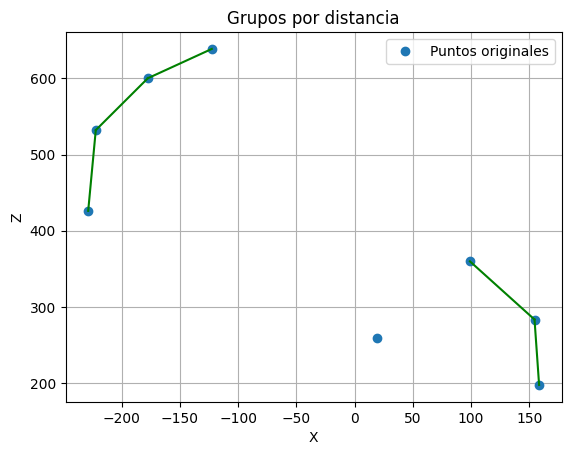

label 0
label 1


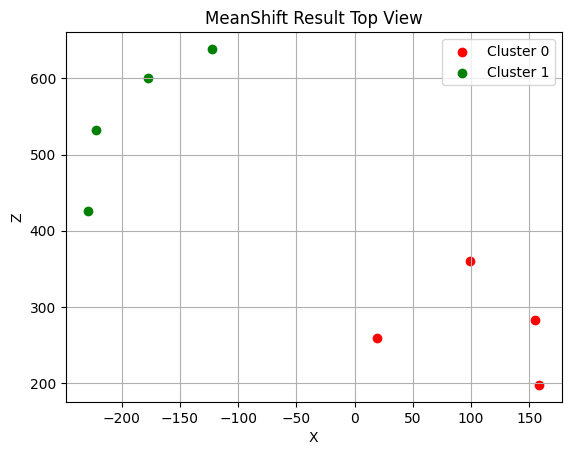

label 0
label 1


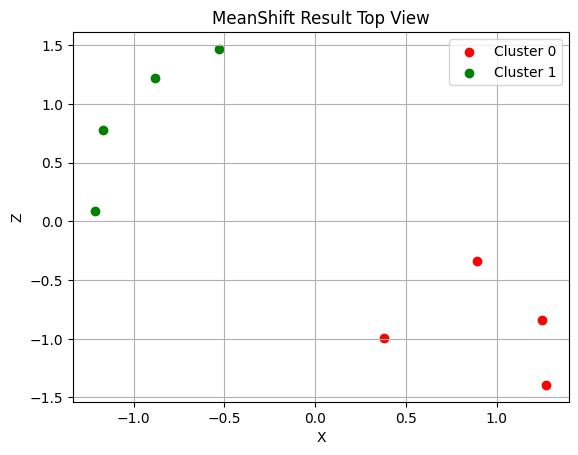

In [13]:
plt.figure()

if is_xy:
    plt.plot(puntos[:, 0], -puntos[:, 1], 'o', label='Puntos originales')
else:
    plt.plot(puntos[:, 0], puntos[:, 1], 'o', label='Puntos originales')

for index in range(len(camino) - 1):
    p1 = camino[index][0]
    p2 = camino[index + 1][0]
    distancia = camino[index + 1][1]
    if distancia < 115: #120
        print("p1", p1, "p2", p2, distancia)
        if is_xy:
            plt.plot([p1[0], p2[0]], [-p1[1], -p2[1]], 'g-')
        else:
            plt.plot([p1[0], p2[0]], [p1[1], p2[1]], 'g-')
    else:
        print("p1", p1, "p2", p2)
        print("distancia mayor a 115", distancia)

plt.xlabel('X')
if is_xy:
    plt.ylabel('Y')
else:
    plt.ylabel('Z')
plt.title('Grupos por distancia')
plt.legend()
plt.grid(True)
plt.show()

# --------------------------------------------------------------------------------------------

plt.figure()

list_colors = ['r', 'g', 'b', 'y', 'm', 'c', 'k']
# Graficar los puntos coloreados por cluster
for label in np.unique(labels_nomal):
    print("label", label)
    cluster_points = puntos[labels_nomal == label]
    if is_xy:
        plt.scatter(cluster_points[:, 0], -cluster_points[:, 1], 
                    c=list_colors[label % len(list_colors)], 
                    label=f'Cluster {label}')
    else:
        plt.scatter(cluster_points[:, 0], cluster_points[:, 1], 
                    c=list_colors[label % len(list_colors)], 
                    label=f'Cluster {label}')

# # Graficar los centros de los clusters
# plt.scatter(cluster_centers[:, 0], cluster_centers[:, 1], 
#             c='black', marker='x', s=100, label='Centros de Clusters')

plt.xlabel('X')
if is_xy:
    plt.ylabel('Y')
else:
    plt.ylabel('Z')
if is_xy:
    plt.title('MeanShift Result Front View')
else:
    plt.title('MeanShift Result Top View')
plt.legend()
plt.grid(True)
plt.show()

# --------------------------------------------------------------------------------------------

plt.figure()

list_colors = ['r', 'g', 'b', 'y', 'm', 'c', 'k']
# Graficar los puntos coloreados por cluster
for label in np.unique(labels):
    print("label", label)
    cluster_points = X[labels == label]
    if is_xy:
        plt.scatter(cluster_points[:, 0], -cluster_points[:, 1], 
                    c=list_colors[label % len(list_colors)], 
                    label=f'Cluster {label}')
    else:
        plt.scatter(cluster_points[:, 0], cluster_points[:, 1], 
                    c=list_colors[label % len(list_colors)], 
                    label=f'Cluster {label}')

# # Graficar los centros de los clusters
# plt.scatter(cluster_centers[:, 0], cluster_centers[:, 1], 
#             c='black', marker='x', s=100, label='Centros de Clusters')

plt.xlabel('X')
if is_xy:
    plt.ylabel('Y')
else:
    plt.ylabel('Z')


if is_xy:
    plt.title('MeanShift Result Front View')
else:
    plt.title('MeanShift Result Top View')
plt.legend()
plt.grid(True)
plt.show()

In [14]:
len(list_centroides_2D), len(list_list_centroides)

(120, 120)

In [15]:
grupos_by_escena = []

for index, puntos_escena_2d in enumerate(list_centroides_2D):
    puntos_escena_3d = list_list_centroides[index][:, [0, 2]]
    
    grupos_meanshift = []
    for puntos in [puntos_escena_2d, puntos_escena_3d]:
        X = StandardScaler().fit_transform(puntos)

        # Estimar el bandwidth
        bandwidth = estimate_bandwidth(X, quantile=0.5)

        # Crear el modelo MeanShift
        mean_shift = MeanShift(bandwidth=bandwidth, bin_seeding=True)

        # Ajustar el modelo a los datos
        mean_shift.fit(X)

        # Obtener las etiquetas de los clusters
        labels = mean_shift.labels_

        # Obtener los centros de los clusters
        cluster_centers = mean_shift.cluster_centers_

        grupos_meanshift.append(len(np.unique(labels)))
    print("Meanshift")
    print("Tamaño de grupos 2D", grupos_meanshift[0], "Tamaño de grupos 3D", grupos_meanshift[1])

    # grupos por distancia
    puntos_sorted_2d = puntos_escena_2d[np.argsort(puntos_escena_2d[:, 0])]
    camino_2d, distancia_total_2d = vecino_mas_cercano(puntos_sorted_2d.tolist())
    puntos_sorted_3d = puntos_escena_3d[np.argsort(puntos_escena_3d[:, 1])]
    camino_3d, distancia_total_3d = vecino_mas_cercano(puntos_sorted_3d.tolist())

    grupo_distancia = []
    for camino in [camino_2d, camino_3d]:
        count_groups = 0
        for index in range(len(camino) - 1):
            p1 = camino[index][0]
            p2 = camino[index + 1][0]
            distancia = camino[index + 1][1]
            if distancia > 115:
                count_groups += 1
        grupo_distancia.append(count_groups)

    print("Distancia")
    print("Tamaño de grupos 2D", grupo_distancia[0], "Tamaño de grupos 3D", grupo_distancia[1])
    print("-"*20)
    grupos_by_escena.append({
        "meanshift": {
            "2D": grupos_meanshift[0], 
            "3D": grupos_meanshift[1]
        },
        "distancia": {
            "2D": grupo_distancia[0],
            "3D": grupo_distancia[1]
        }
    })
    

Meanshift
Tamaño de grupos 2D 3 Tamaño de grupos 3D 2
Distancia
Tamaño de grupos 2D 6 Tamaño de grupos 3D 3
--------------------
Meanshift
Tamaño de grupos 2D 2 Tamaño de grupos 3D 2
Distancia
Tamaño de grupos 2D 7 Tamaño de grupos 3D 4
--------------------
Meanshift
Tamaño de grupos 2D 3 Tamaño de grupos 3D 3
Distancia
Tamaño de grupos 2D 7 Tamaño de grupos 3D 3
--------------------
Meanshift
Tamaño de grupos 2D 3 Tamaño de grupos 3D 3
Distancia
Tamaño de grupos 2D 7 Tamaño de grupos 3D 3
--------------------
Meanshift
Tamaño de grupos 2D 3 Tamaño de grupos 3D 3
Distancia
Tamaño de grupos 2D 7 Tamaño de grupos 3D 3
--------------------
Meanshift
Tamaño de grupos 2D 2 Tamaño de grupos 3D 2
Distancia
Tamaño de grupos 2D 7 Tamaño de grupos 3D 3
--------------------
Meanshift
Tamaño de grupos 2D 2 Tamaño de grupos 3D 2
Distancia
Tamaño de grupos 2D 7 Tamaño de grupos 3D 3
--------------------
Meanshift
Tamaño de grupos 2D 3 Tamaño de grupos 3D 2
Distancia
Tamaño de grupos 2D 7 Tamaño de g

/home/admin-cidis/.local/lib/python3.10/site-packages/sklearn/cluster/_mean_shift.py:293: UserWarning: Binning data failed with provided bin_size=1.018791, using data points as seeds.
  warnings.warn(
/home/admin-cidis/.local/lib/python3.10/site-packages/sklearn/cluster/_mean_shift.py:293: UserWarning: Binning data failed with provided bin_size=1.032482, using data points as seeds.
  warnings.warn(
/home/admin-cidis/.local/lib/python3.10/site-packages/sklearn/cluster/_mean_shift.py:293: UserWarning: Binning data failed with provided bin_size=1.110097, using data points as seeds.
  warnings.warn(
/home/admin-cidis/.local/lib/python3.10/site-packages/sklearn/cluster/_mean_shift.py:293: UserWarning: Binning data failed with provided bin_size=0.768734, using data points as seeds.
  warnings.warn(
/home/admin-cidis/.local/lib/python3.10/site-packages/sklearn/cluster/_mean_shift.py:293: UserWarning: Binning data failed with provided bin_size=1.404327, using data points as seeds.
  warnings.w

Meanshift
Tamaño de grupos 2D 3 Tamaño de grupos 3D 2
Distancia
Tamaño de grupos 2D 5 Tamaño de grupos 3D 4
--------------------
Meanshift
Tamaño de grupos 2D 3 Tamaño de grupos 3D 2
Distancia
Tamaño de grupos 2D 5 Tamaño de grupos 3D 3
--------------------
Meanshift
Tamaño de grupos 2D 3 Tamaño de grupos 3D 4
Distancia
Tamaño de grupos 2D 4 Tamaño de grupos 3D 3
--------------------
Meanshift
Tamaño de grupos 2D 3 Tamaño de grupos 3D 2
Distancia
Tamaño de grupos 2D 7 Tamaño de grupos 3D 4
--------------------
Meanshift
Tamaño de grupos 2D 2 Tamaño de grupos 3D 2
Distancia
Tamaño de grupos 2D 6 Tamaño de grupos 3D 3
--------------------
Meanshift
Tamaño de grupos 2D 3 Tamaño de grupos 3D 2
Distancia
Tamaño de grupos 2D 7 Tamaño de grupos 3D 4
--------------------
Meanshift
Tamaño de grupos 2D 3 Tamaño de grupos 3D 2
Distancia
Tamaño de grupos 2D 7 Tamaño de grupos 3D 4
--------------------
Meanshift
Tamaño de grupos 2D 2 Tamaño de grupos 3D 2
Distancia
Tamaño de grupos 2D 6 Tamaño de g

/home/admin-cidis/.local/lib/python3.10/site-packages/sklearn/cluster/_mean_shift.py:293: UserWarning: Binning data failed with provided bin_size=1.426886, using data points as seeds.
  warnings.warn(
/home/admin-cidis/.local/lib/python3.10/site-packages/sklearn/cluster/_mean_shift.py:293: UserWarning: Binning data failed with provided bin_size=1.628525, using data points as seeds.
  warnings.warn(
/home/admin-cidis/.local/lib/python3.10/site-packages/sklearn/cluster/_mean_shift.py:293: UserWarning: Binning data failed with provided bin_size=1.448460, using data points as seeds.
  warnings.warn(
/home/admin-cidis/.local/lib/python3.10/site-packages/sklearn/cluster/_mean_shift.py:293: UserWarning: Binning data failed with provided bin_size=1.406650, using data points as seeds.
  warnings.warn(
/home/admin-cidis/.local/lib/python3.10/site-packages/sklearn/cluster/_mean_shift.py:293: UserWarning: Binning data failed with provided bin_size=1.421080, using data points as seeds.
  warnings.w

Meanshift
Tamaño de grupos 2D 2 Tamaño de grupos 3D 1
Distancia
Tamaño de grupos 2D 8 Tamaño de grupos 3D 2
--------------------
Meanshift
Tamaño de grupos 2D 2 Tamaño de grupos 3D 1
Distancia
Tamaño de grupos 2D 8 Tamaño de grupos 3D 2
--------------------
Meanshift
Tamaño de grupos 2D 2 Tamaño de grupos 3D 1
Distancia
Tamaño de grupos 2D 8 Tamaño de grupos 3D 3
--------------------
Meanshift
Tamaño de grupos 2D 2 Tamaño de grupos 3D 1
Distancia
Tamaño de grupos 2D 8 Tamaño de grupos 3D 2
--------------------
Meanshift
Tamaño de grupos 2D 2 Tamaño de grupos 3D 2
Distancia
Tamaño de grupos 2D 6 Tamaño de grupos 3D 4
--------------------
Meanshift
Tamaño de grupos 2D 1 Tamaño de grupos 3D 3
Distancia
Tamaño de grupos 2D 6 Tamaño de grupos 3D 3
--------------------
Meanshift
Tamaño de grupos 2D 2 Tamaño de grupos 3D 2
Distancia
Tamaño de grupos 2D 6 Tamaño de grupos 3D 3
--------------------
Meanshift
Tamaño de grupos 2D 1 Tamaño de grupos 3D 3
Distancia
Tamaño de grupos 2D 6 Tamaño de g

/home/admin-cidis/.local/lib/python3.10/site-packages/sklearn/cluster/_mean_shift.py:293: UserWarning: Binning data failed with provided bin_size=1.376672, using data points as seeds.
  warnings.warn(
/home/admin-cidis/.local/lib/python3.10/site-packages/sklearn/cluster/_mean_shift.py:293: UserWarning: Binning data failed with provided bin_size=1.500836, using data points as seeds.
  warnings.warn(
/home/admin-cidis/.local/lib/python3.10/site-packages/sklearn/cluster/_mean_shift.py:293: UserWarning: Binning data failed with provided bin_size=1.608297, using data points as seeds.
  warnings.warn(
/home/admin-cidis/.local/lib/python3.10/site-packages/sklearn/cluster/_mean_shift.py:293: UserWarning: Binning data failed with provided bin_size=1.536524, using data points as seeds.
  warnings.warn(


Meanshift
Tamaño de grupos 2D 3 Tamaño de grupos 3D 2
Distancia
Tamaño de grupos 2D 6 Tamaño de grupos 3D 3
--------------------
Meanshift
Tamaño de grupos 2D 3 Tamaño de grupos 3D 2
Distancia
Tamaño de grupos 2D 6 Tamaño de grupos 3D 3
--------------------
Meanshift
Tamaño de grupos 2D 3 Tamaño de grupos 3D 2
Distancia
Tamaño de grupos 2D 6 Tamaño de grupos 3D 3
--------------------
Meanshift
Tamaño de grupos 2D 3 Tamaño de grupos 3D 2
Distancia
Tamaño de grupos 2D 6 Tamaño de grupos 3D 3
--------------------
Meanshift
Tamaño de grupos 2D 3 Tamaño de grupos 3D 2
Distancia
Tamaño de grupos 2D 6 Tamaño de grupos 3D 3
--------------------
Meanshift
Tamaño de grupos 2D 1 Tamaño de grupos 3D 2
Distancia
Tamaño de grupos 2D 6 Tamaño de grupos 3D 3
--------------------
Meanshift
Tamaño de grupos 2D 1 Tamaño de grupos 3D 2
Distancia
Tamaño de grupos 2D 6 Tamaño de grupos 3D 3
--------------------
Meanshift
Tamaño de grupos 2D 1 Tamaño de grupos 3D 2
Distancia
Tamaño de grupos 2D 6 Tamaño de g

/home/admin-cidis/.local/lib/python3.10/site-packages/sklearn/cluster/_mean_shift.py:293: UserWarning: Binning data failed with provided bin_size=1.011902, using data points as seeds.
  warnings.warn(
/home/admin-cidis/.local/lib/python3.10/site-packages/sklearn/cluster/_mean_shift.py:293: UserWarning: Binning data failed with provided bin_size=1.009891, using data points as seeds.
  warnings.warn(


Meanshift
Tamaño de grupos 2D 2 Tamaño de grupos 3D 4
Distancia
Tamaño de grupos 2D 4 Tamaño de grupos 3D 2
--------------------
Meanshift
Tamaño de grupos 2D 2 Tamaño de grupos 3D 2
Distancia
Tamaño de grupos 2D 4 Tamaño de grupos 3D 1
--------------------
Meanshift
Tamaño de grupos 2D 3 Tamaño de grupos 3D 4
Distancia
Tamaño de grupos 2D 4 Tamaño de grupos 3D 2
--------------------
Meanshift
Tamaño de grupos 2D 2 Tamaño de grupos 3D 3
Distancia
Tamaño de grupos 2D 3 Tamaño de grupos 3D 2
--------------------
Meanshift
Tamaño de grupos 2D 3 Tamaño de grupos 3D 3
Distancia
Tamaño de grupos 2D 3 Tamaño de grupos 3D 1
--------------------
Meanshift
Tamaño de grupos 2D 2 Tamaño de grupos 3D 2
Distancia
Tamaño de grupos 2D 8 Tamaño de grupos 3D 3
--------------------
Meanshift
Tamaño de grupos 2D 2 Tamaño de grupos 3D 2
Distancia
Tamaño de grupos 2D 8 Tamaño de grupos 3D 3
--------------------
Meanshift
Tamaño de grupos 2D 2 Tamaño de grupos 3D 2
Distancia
Tamaño de grupos 2D 8 Tamaño de g

In [16]:
len(grupos_by_escena)

120

In [17]:
# Etiquetas verdaderas (ground truth)
etiquetas_verdaderas_meanshift_2D = []
etiquetas_verdaderas_meanshift_3D = []
etiquetas_verdaderas_distancia_2D = []
etiquetas_verdaderas_distancia_3D = []

# Etiquetas predichas por el algoritmo (por ejemplo, MeanShift)
etiquetas_predichas_meanshift_2D = []
etiquetas_predichas_meanshift_3D = []
etiquetas_predichas_distancia_2D = []
etiquetas_predichas_distancia_3D = []

print("Grupos por escena Meanshift")
for i in range(int(len(grupos_by_escena)/5)):

    if i*5 >= 60:
        grupo_total = 3
        print("----------- 3 grupos")
    else:
        grupo_total = 2
        print("----------- 2 grupos")
        
    print(i*5, (i+1)*5)
    for j in grupos_by_escena[i*5:(i+1)*5]:
        etiquetas_verdaderas_meanshift_2D.append(grupo_total)
        etiquetas_verdaderas_meanshift_3D.append(grupo_total)
        etiquetas_verdaderas_distancia_2D.append(grupo_total)
        etiquetas_verdaderas_distancia_3D.append(grupo_total)
        
        print(j["meanshift"])
        etiquetas_predichas_meanshift_2D.append(j["meanshift"]["2D"])
        etiquetas_predichas_meanshift_3D.append(j["meanshift"]["3D"])
        print(j["distancia"])
        etiquetas_predichas_distancia_2D.append(j["distancia"]["2D"])
        etiquetas_predichas_distancia_3D.append(j["distancia"]["3D"])


etiquetas_verdaderas_meanshift_2D = np.array(etiquetas_verdaderas_meanshift_2D)
etiquetas_verdaderas_meanshift_3D = np.array(etiquetas_verdaderas_meanshift_3D)
etiquetas_verdaderas_distancia_2D = np.array(etiquetas_verdaderas_distancia_2D)
etiquetas_verdaderas_distancia_3D = np.array(etiquetas_verdaderas_distancia_3D)
etiquetas_predichas_meanshift_2D = np.array(etiquetas_predichas_meanshift_2D)
etiquetas_predichas_meanshift_3D = np.array(etiquetas_predichas_meanshift_3D)
etiquetas_predichas_distancia_2D = np.array(etiquetas_predichas_distancia_2D)
etiquetas_predichas_distancia_3D = np.array(etiquetas_predichas_distancia_3D)

Grupos por escena Meanshift
----------- 2 grupos
0 5
{'2D': 3, '3D': 2}
{'2D': 6, '3D': 3}
{'2D': 2, '3D': 2}
{'2D': 7, '3D': 4}
{'2D': 3, '3D': 3}
{'2D': 7, '3D': 3}
{'2D': 3, '3D': 3}
{'2D': 7, '3D': 3}
{'2D': 3, '3D': 3}
{'2D': 7, '3D': 3}
----------- 2 grupos
5 10
{'2D': 2, '3D': 2}
{'2D': 7, '3D': 3}
{'2D': 2, '3D': 2}
{'2D': 7, '3D': 3}
{'2D': 3, '3D': 2}
{'2D': 7, '3D': 3}
{'2D': 2, '3D': 2}
{'2D': 7, '3D': 3}
{'2D': 3, '3D': 2}
{'2D': 7, '3D': 3}
----------- 2 grupos
10 15
{'2D': 3, '3D': 2}
{'2D': 5, '3D': 4}
{'2D': 3, '3D': 2}
{'2D': 5, '3D': 4}
{'2D': 3, '3D': 2}
{'2D': 5, '3D': 4}
{'2D': 3, '3D': 2}
{'2D': 5, '3D': 3}
{'2D': 3, '3D': 4}
{'2D': 4, '3D': 3}
----------- 2 grupos
15 20
{'2D': 3, '3D': 2}
{'2D': 7, '3D': 4}
{'2D': 2, '3D': 2}
{'2D': 6, '3D': 3}
{'2D': 3, '3D': 2}
{'2D': 7, '3D': 4}
{'2D': 3, '3D': 2}
{'2D': 7, '3D': 4}
{'2D': 2, '3D': 2}
{'2D': 6, '3D': 3}
----------- 2 grupos
20 25
{'2D': 2, '3D': 2}
{'2D': 7, '3D': 4}
{'2D': 3, '3D': 2}
{'2D': 7, '3D': 3}
{'2D

In [18]:
# Crear la matriz de confusión
matriz_confusion_2d = confusion_matrix(etiquetas_verdaderas_meanshift_2D, etiquetas_predichas_meanshift_2D)
matriz_confusion_3d = confusion_matrix(etiquetas_verdaderas_meanshift_3D, etiquetas_predichas_meanshift_3D)
matriz_confusion_distancia_2d = confusion_matrix(etiquetas_verdaderas_distancia_2D, etiquetas_predichas_distancia_2D)
matriz_confusion_distancia_3d = confusion_matrix(etiquetas_verdaderas_distancia_3D, etiquetas_predichas_distancia_3D)

In [19]:
np.unique(etiquetas_verdaderas_meanshift_2D), np.unique(etiquetas_predichas_meanshift_2D), np.unique(etiquetas_verdaderas_meanshift_3D), np.unique(etiquetas_predichas_meanshift_3D)

(array([2, 3]), array([1, 2, 3]), array([2, 3]), array([1, 2, 3, 4]))

In [20]:
np.unique(etiquetas_verdaderas_distancia_2D), np.unique(etiquetas_predichas_distancia_2D), np.unique(etiquetas_verdaderas_distancia_3D), np.unique(etiquetas_predichas_distancia_3D)

(array([2, 3]), array([3, 4, 5, 6, 7, 8]), array([2, 3]), array([1, 2, 3, 4]))

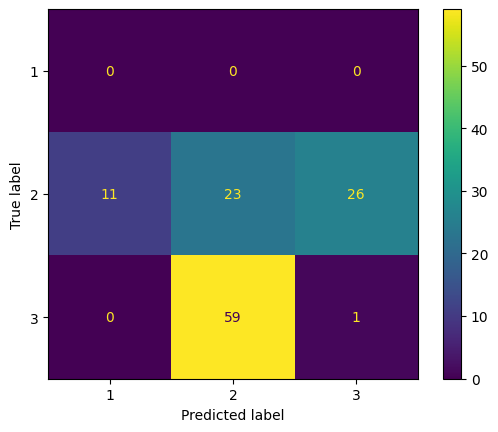

In [21]:
cm_display = ConfusionMatrixDisplay(confusion_matrix = matriz_confusion_2d, display_labels = np.unique(etiquetas_predichas_meanshift_2D))

cm_display.plot()
plt.show()

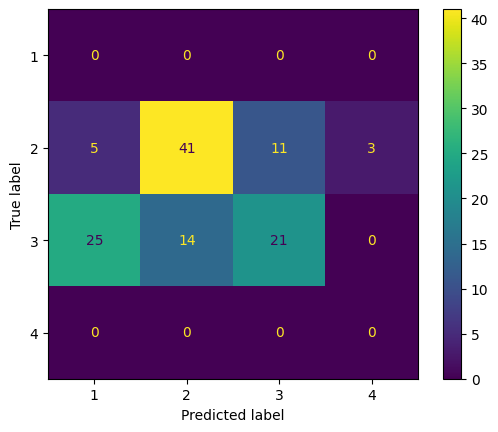

In [22]:
cm_display = ConfusionMatrixDisplay(confusion_matrix = matriz_confusion_3d, display_labels = np.unique(etiquetas_predichas_meanshift_3D))

cm_display.plot()
plt.show()

In [38]:
# sacar el porcentaje de efectividad de matriz_confusion_2d
total = 0
for i in range(len(matriz_confusion_2d)):
    total += matriz_confusion_2d[i][i]
eficiencia_general = round(total / np.sum(matriz_confusion_2d), 4)

# tasa de efectividad para el indicie 1 de matriz_confusion_3d
tasa_2 = round(matriz_confusion_2d[1][1] / np.sum(matriz_confusion_2d[1]), 4)
tasa_3 = round(matriz_confusion_2d[2][2] / np.sum(matriz_confusion_2d[2]), 4)
print("eficiencia general", eficiencia_general, "tasa 2", tasa_2, "tasa 3", tasa_3)

eficiencia general 0.2 tasa 2 0.3833 tasa 3 0.0167


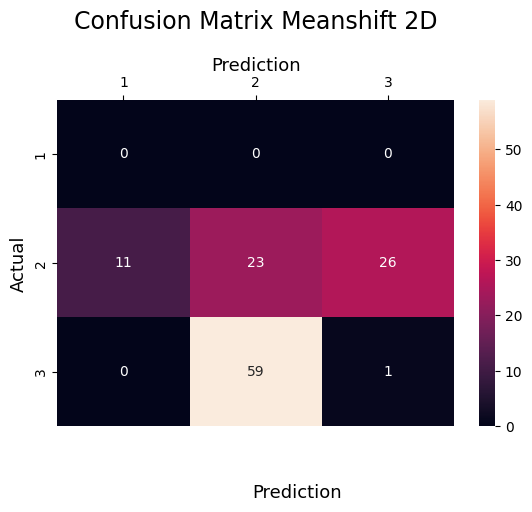

In [24]:
sns.heatmap(matriz_confusion_2d, 
            annot=True,
            fmt='g', 
            xticklabels=np.unique(etiquetas_predichas_meanshift_2D),
            yticklabels=np.unique(etiquetas_predichas_meanshift_2D))
plt.ylabel('Actual', fontsize=13)
plt.title('Confusion Matrix Meanshift 2D', fontsize=17, pad=20)
plt.gca().xaxis.set_label_position('top') 
plt.xlabel('Prediction', fontsize=13)
plt.gca().xaxis.tick_top()

plt.gca().figure.subplots_adjust(bottom=0.2)
plt.gca().figure.text(0.5, 0.05, 'Prediction', ha='center', fontsize=13)
plt.show()

In [39]:
# sacar el porcentaje de efectividad de matriz_confusion_3d
total = 0
for i in range(len(matriz_confusion_3d)):
    total += matriz_confusion_3d[i][i]
eficiencia_general = round(total / np.sum(matriz_confusion_3d), 4)

# tasa de efectividad para el indicie 1 de matriz_confusion_3d
tasa_2 = round(matriz_confusion_3d[1][1] / np.sum(matriz_confusion_3d[1]), 4)
tasa_3 = round(matriz_confusion_3d[2][2] / np.sum(matriz_confusion_3d[2]), 4)
print("eficiencia general", eficiencia_general, "tasa 2", tasa_2, "tasa 3", tasa_3)


eficiencia general 0.5167 tasa 2 0.6833 tasa 3 0.35


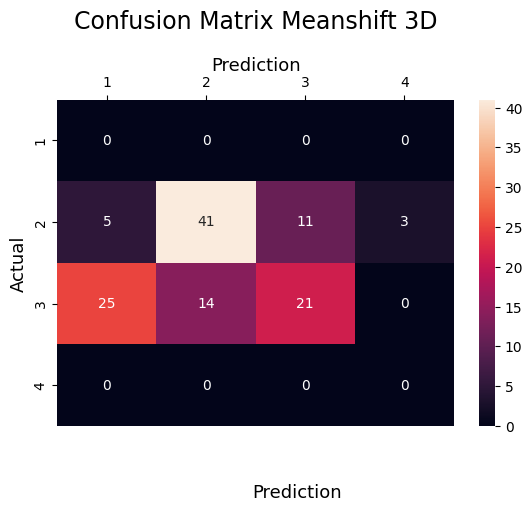

In [25]:
sns.heatmap(matriz_confusion_3d, 
            annot=True,
            fmt='g', 
            xticklabels=np.unique(etiquetas_predichas_meanshift_3D),
            yticklabels=np.unique(etiquetas_predichas_meanshift_3D))
plt.ylabel('Actual', fontsize=13)
plt.title('Confusion Matrix Meanshift 3D', fontsize=17, pad=20)
plt.gca().xaxis.set_label_position('top') 
plt.xlabel('Prediction', fontsize=13)
plt.gca().xaxis.tick_top()

plt.gca().figure.subplots_adjust(bottom=0.2)
plt.gca().figure.text(0.5, 0.05, 'Prediction', ha='center', fontsize=13)
plt.show()

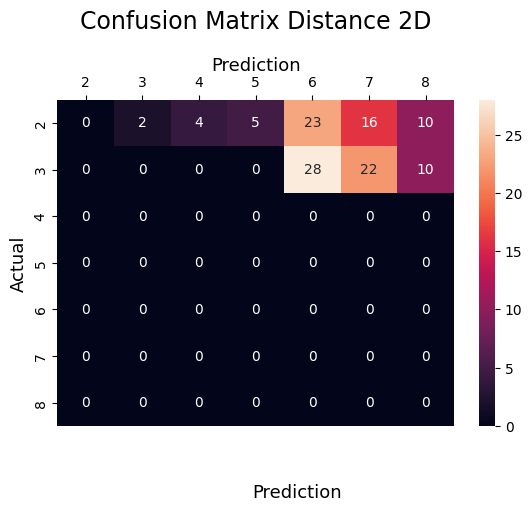

In [26]:
etiquetas = np.unique(etiquetas_predichas_distancia_2D)
etiquetas = np.insert(etiquetas, 0, 2)   

sns.heatmap(matriz_confusion_distancia_2d, 
            annot=True,
            fmt='g', 
            xticklabels=etiquetas,
            yticklabels=etiquetas)
plt.ylabel('Actual', fontsize=13)
plt.title('Confusion Matrix Distance 2D', fontsize=17, pad=20)
plt.gca().xaxis.set_label_position('top') 
plt.xlabel('Prediction', fontsize=13)
plt.gca().xaxis.tick_top()

plt.gca().figure.subplots_adjust(bottom=0.2)
plt.gca().figure.text(0.5, 0.05, 'Prediction', ha='center', fontsize=13)
plt.show()

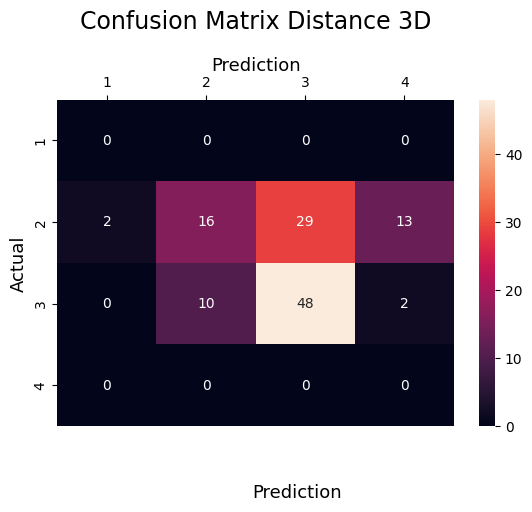

In [27]:
sns.heatmap(matriz_confusion_distancia_3d, 
            annot=True,
            fmt='g', 
            xticklabels=np.unique(etiquetas_predichas_distancia_3D),
            yticklabels=np.unique(etiquetas_predichas_distancia_3D))
plt.ylabel('Actual', fontsize=13)
plt.title('Confusion Matrix Distance 3D', fontsize=17, pad=20)
plt.gca().xaxis.set_label_position('top') 
plt.xlabel('Prediction', fontsize=13)
plt.gca().xaxis.tick_top()

plt.gca().figure.subplots_adjust(bottom=0.2)
plt.gca().figure.text(0.5, 0.05, 'Prediction', ha='center', fontsize=13)
plt.show()